# 📈 Linear Regression — From Intuition to a Real-World Case Study

**A complete, self-contained guide.** We go from *"draw a line through points"* to the full statistical machinery, and we implement everything **three ways**: from scratch (NumPy), with **statsmodels** (statistical inference) and with **scikit-learn** (machine-learning workflow).

### Table of contents
| # | Section | What you will learn |
|---|---------|--------------------|
| 0 | Setup | Libraries & plotting style |
| 1 | Intuition | What regression is, what "best line" means |
| 2 | Cost / loss functions | SSE, MSE, RMSE, MAE, MAPE, Huber, R², Adjusted R², cost surface, outlier sensitivity |
| 3 | Solving for the coefficients | Calculus derivation, Normal Equation, geometry (projection), Gradient Descent, SGD/mini-batch |
| 4 | Statistical inference | Variance decomposition, standard errors, t-tests, F-test, confidence & prediction intervals, AIC/BIC |
| 5 | Multiple regression | Matrix form, "holding others constant" (Frisch–Waugh–Lovell), multicollinearity & VIF |
| 6 | Assumptions & diagnostics | Linearity, independence, homoscedasticity, normality, leverage, Cook's distance |
| 7 | **statsmodels** | Reading `summary()` line by line, formulas, robust SEs, prediction intervals |
| 8 | **scikit-learn** | `LinearRegression`, pipelines, cross-validation, SGDRegressor, comparing all methods |
| 9 | Regularization | Ridge, Lasso, Elastic Net, geometry of L1 vs L2, coefficient paths, CV |
| 10 | Bias–variance & overfitting | Polynomial regression, learning curves |
| 11 | 🏠 **Real-life case study** | End-to-end house-price model: EDA → cleaning → modelling → diagnostics → business insight |
| 12 | Cheat-sheet | Formulas, pitfalls, exercises |

> **Requirements:** `pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels`
> Run the notebook top-to-bottom; every random experiment uses a fixed seed so results are reproducible.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# statsmodels is used in Section 7 and in the case study
try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
except ImportError:
    print("statsmodels not found -> run: pip install statsmodels")

plt.rcParams.update({
    "figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
})
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Setup complete ✅")

statsmodels not found -> run: pip install statsmodels
Setup complete ✅


## 1. What is Linear Regression? (Intuition)

**Regression** = predicting a *continuous number* (price, score, temperature, sales …) from one or more inputs.

### The model
For **one** input (simple linear regression):

$$
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i
$$

| Symbol | Name | Meaning |
|---|---|---|
| $y_i$ | response / target | what we want to predict |
| $x_i$ | predictor / feature | what we use to predict |
| $\beta_0$ | intercept | predicted $y$ when $x=0$ |
| $\beta_1$ | slope | **average change in $y$ for a 1-unit increase in $x$** |
| $\varepsilon_i$ | error / noise | everything the line cannot explain (other variables, randomness, measurement error) |

For **many** inputs (multiple linear regression):

$$
y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \dots + \beta_p x_{ip} + \varepsilon_i
\quad\Longleftrightarrow\quad
\mathbf{y} = \mathbf{X}\boldsymbol\beta + \boldsymbol\varepsilon
$$

### Two important clarifications
* **"Linear" means linear in the *parameters* $\beta$**, not in $x$. The model $y=\beta_0+\beta_1x+\beta_2x^2$ is still a *linear* regression (it is linear in $\beta$).
* **Population vs. sample.** The true $\beta$'s are unknown constants. We compute *estimates* $\hat\beta$ from data. The fitted line is $\hat y = \hat\beta_0+\hat\beta_1 x$, and the **residual** is $e_i = y_i-\hat y_i$ (the observed error). Residuals $e_i$ are *estimates* of the unobservable errors $\varepsilon_i$.

### Running example
A student's exam score vs. hours studied (synthetic data, true relationship: `score = 35 + 5.5 × hours + noise`).

,hours,score
0,7.9656,83.2703
1,4.9499,65.4834
2,8.7274,79.0075
3,7.2763,76.4127
4,1.8476,45.8619


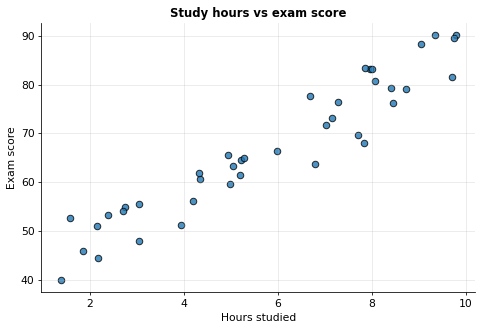

In [2]:
rng = np.random.default_rng(42)
n = 40
hours = rng.uniform(1, 10, n)
score = 35 + 5.5 * hours + rng.normal(0, 6, n)      # true beta0=35, true beta1=5.5, noise sd=6
df_study = pd.DataFrame({"hours": hours, "score": score})

x = df_study["hours"].values
y = df_study["score"].values
display(df_study.head())

fig, ax = plt.subplots()
ax.scatter(x, y, s=45, edgecolor="k", alpha=.8)
ax.set(xlabel="Hours studied", ylabel="Exam score", title="Study hours vs exam score")
plt.show()

### Which line is "best"?
Infinitely many lines can be drawn through this cloud. Let's compare three of them by adding up how far each is from the data (sum of squared vertical distances, **SSE**).

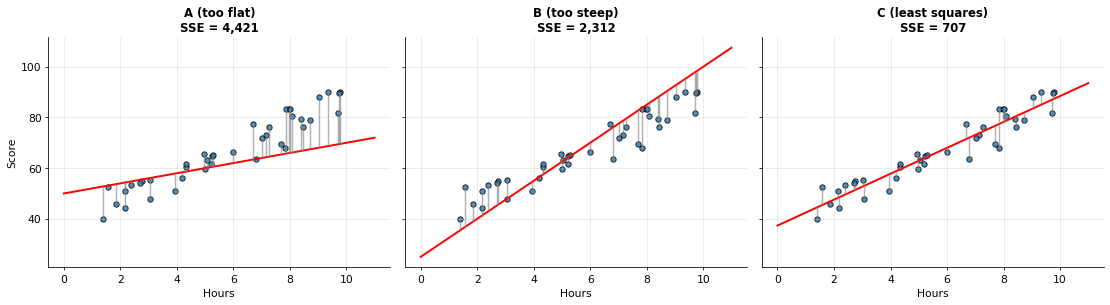

In [3]:
b1_hat, b0_hat = np.polyfit(x, y, 1)      # least-squares line (we derive this by hand in Section 3)
def sse(b0, b1): return np.sum((y - (b0 + b1 * x))**2)

candidates = {"A (too flat)": (50, 2.0), "B (too steep)": (25, 7.5), "C (least squares)": (b0_hat, b1_hat)}
xs = np.linspace(0, 11, 100)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (name, (b0, b1)) in zip(axes, candidates.items()):
    ax.scatter(x, y, s=30, edgecolor="k", alpha=.8)
    ax.plot(xs, b0 + b1 * xs, "r", lw=2)
    ax.vlines(x, y, b0 + b1 * x, colors="grey", alpha=.6)
    ax.set_title(f"{name}\nSSE = {sse(b0, b1):,.0f}")
    ax.set_xlabel("Hours")
axes[0].set_ylabel("Score")
plt.tight_layout(); plt.show()

**Take-away:** the "best" line is the one that makes the *total error* as small as possible. To make that precise we must choose an **error measure** – a *cost function* (also called *loss* or *objective*). That is the next section.

## 2. Cost (Loss) Functions & Evaluation Metrics

### 2.1 Residual
$$e_i = y_i - \hat y_i \qquad(\text{actual} - \text{predicted})$$
Positive residual → model *under*-predicted; negative → *over*-predicted.

If we simply summed residuals, positives and negatives would cancel (in OLS they sum to exactly 0!). So we need to make errors non-negative first:

### 2.2 The family of cost functions

| Name | Formula | Units | Key property |
|---|---|---|---|
| **SSE / RSS** (Sum of Squared Errors) | $\displaystyle \sum_{i=1}^n e_i^2$ | $y^2$ | The quantity OLS minimises |
| **MSE** (Mean Squared Error) | $\displaystyle \frac1n\sum e_i^2$ | $y^2$ | Average squared error; smooth & convex |
| **RMSE** | $\displaystyle \sqrt{\text{MSE}}$ | $y$ | Same units as $y$ ("typical error size", penalises big errors) |
| **MAE** (Mean Absolute Error) | $\displaystyle \frac1n\sum \lvert e_i\rvert$ | $y$ | Robust to outliers, not differentiable at 0 |
| **MAPE** | $\displaystyle \frac{100}{n}\sum \left\lvert\frac{e_i}{y_i}\right\rvert$ | % | Scale-free; breaks when $y_i\approx0$ |
| **Huber** (parameter $\delta$) | $\begin{cases}\tfrac12 e^2 & \lvert e\rvert\le\delta\\ \delta(\lvert e\rvert-\tfrac12\delta) & \lvert e\rvert>\delta\end{cases}$ | $y^2$/$y$ | Quadratic near 0, linear in the tails: best of both worlds |
| **Training objective used in gradient descent** | $\displaystyle J(\boldsymbol\beta)=\frac{1}{2n}\sum e_i^2$ | – | The ½ just cancels the 2 when differentiating |

### 2.3 Why *squared* error? (three good reasons)
1. **Calculus-friendly** – smooth, differentiable everywhere, and **convex** (a single bowl-shaped minimum, no local traps).
2. **Closed-form solution** – setting the gradient to zero gives the Normal Equation (Section 3).
3. **Statistical justification (Maximum Likelihood).** If errors are Gaussian, $\varepsilon_i\sim\mathcal N(0,\sigma^2)$, the likelihood is
$$
L(\boldsymbol\beta,\sigma^2)=\prod_i\frac1{\sqrt{2\pi\sigma^2}}\exp\!\Big(-\frac{(y_i-\mathbf x_i^\top\boldsymbol\beta)^2}{2\sigma^2}\Big)
\;\Rightarrow\;
\ell=-\frac n2\ln(2\pi\sigma^2)-\frac1{2\sigma^2}\underbrace{\sum_i (y_i-\mathbf x_i^\top\boldsymbol\beta)^2}_{\text{SSE}}
$$
Maximising $\ell$ over $\boldsymbol\beta$ is *exactly* minimising SSE. **OLS = MLE under Gaussian noise.** (Likewise, Laplace-distributed errors ⇒ minimising MAE.)
Also, the **Gauss–Markov theorem** says OLS is the *Best Linear Unbiased Estimator (BLUE)* under mild assumptions (Section 6).

### 2.4 Shapes of the losses
The picture below shows how each loss treats an error of size $e$, and the *gradient* (how hard it "pushes" the model to fix that error).

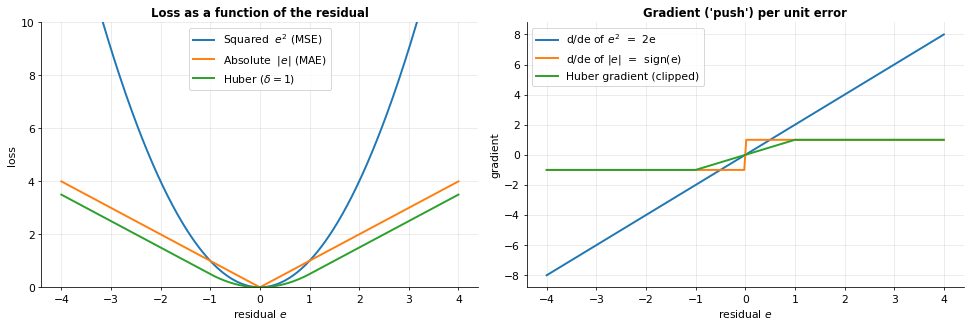

In [4]:
r = np.linspace(-4, 4, 401)
def huber(r, d=1.0): return np.where(np.abs(r) <= d, 0.5 * r**2, d * (np.abs(r) - 0.5 * d))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
ax[0].plot(r, r**2, label="Squared  $e^2$ (MSE)", lw=2)
ax[0].plot(r, np.abs(r), label="Absolute  $|e|$ (MAE)", lw=2)
ax[0].plot(r, huber(r), label="Huber ($\\delta=1$)", lw=2)
ax[0].set(title="Loss as a function of the residual", xlabel="residual $e$", ylabel="loss", ylim=(0, 10)); ax[0].legend()

ax[1].plot(r, 2 * r, label="d/de of $e^2$  =  2e", lw=2)
ax[1].plot(r, np.sign(r), label="d/de of $|e|$  =  sign(e)", lw=2)
ax[1].plot(r, np.clip(r, -1, 1), label="Huber gradient (clipped)", lw=2)
ax[1].set(title="Gradient ('push') per unit error", xlabel="residual $e$", ylabel="gradient"); ax[1].legend()
plt.tight_layout(); plt.show()

**Reading the plot**
* **Squared loss:** an error of 4 costs 16, which is 4× the cost of an error of 2 (cost 4). Its gradient grows linearly with the error, so **one huge outlier dominates the fit**.
* **Absolute loss:** every unit of error costs the same; outliers have a bounded influence (gradient is only ±1) but the kink at 0 makes optimisation harder.
* **Huber:** behaves like squared loss for small errors (smooth) and like absolute loss for large ones (robust).

### 2.5 Residuals vs squared residuals on our data

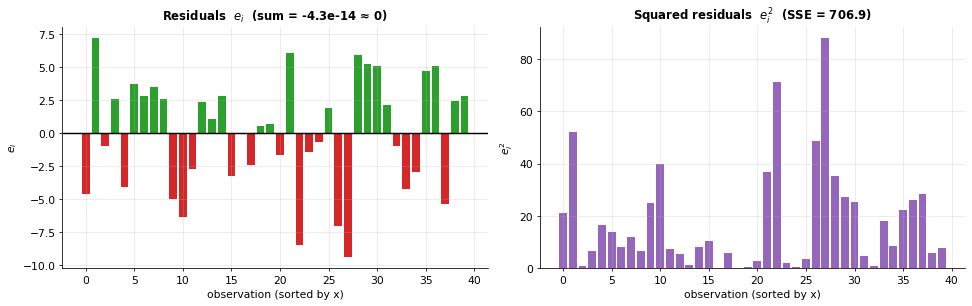

In [5]:
X1 = np.c_[np.ones(len(x)), x]
yhat = b0_hat + b1_hat * x
res = y - yhat

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
order = np.argsort(x)
ax[0].bar(range(len(x)), res[order], color=np.where(res[order] > 0, "tab:green", "tab:red"))
ax[0].axhline(0, color="k"); ax[0].set(title=f"Residuals  $e_i$  (sum = {res.sum():.1e} ≈ 0)", xlabel="observation (sorted by x)", ylabel="$e_i$")
ax[1].bar(range(len(x)), res[order]**2, color="tab:purple")
ax[1].set(title=f"Squared residuals  $e_i^2$  (SSE = {np.sum(res**2):,.1f})", xlabel="observation (sorted by x)", ylabel="$e_i^2$")
plt.tight_layout(); plt.show()

### 2.6 Goodness-of-fit metrics: $R^2$ and Adjusted $R^2$

Decompose the total variation of $y$ around its mean:

$$
\underbrace{\sum (y_i-\bar y)^2}_{\text{SST (total)}}=\underbrace{\sum(\hat y_i-\bar y)^2}_{\text{SSR (explained)}}+\underbrace{\sum (y_i-\hat y_i)^2}_{\text{SSE (unexplained)}}
$$

$$
R^2=\frac{\text{SSR}}{\text{SST}}=1-\frac{\text{SSE}}{\text{SST}}\in[0,1]
$$

*Interpretation:* "the fraction of the variance of $y$ explained by the model". $R^2=0$ means the model is no better than always predicting $\bar y$.

**Problem:** $R^2$ *never decreases* when you add a variable — even a random one. So use

$$
R^2_{adj}=1-(1-R^2)\frac{n-1}{n-p-1}
$$

which penalises the number of predictors $p$. (Here $n$ = sample size.)

Let's compute every metric by hand and verify with scikit-learn.

In [6]:
from sklearn import metrics

n_obs, p_pred = len(y), 1
SSE = np.sum(res**2)
SST = np.sum((y - y.mean())**2)
SSR = SST - SSE
MSE, RMSE = SSE / n_obs, np.sqrt(SSE / n_obs)
MAE  = np.mean(np.abs(res))
MAPE = np.mean(np.abs(res / y)) * 100
R2   = 1 - SSE / SST
R2adj = 1 - (1 - R2) * (n_obs - 1) / (n_obs - p_pred - 1)

table = pd.DataFrame({
    "by hand": [SSE, MSE, RMSE, MAE, MAPE, R2, R2adj],
    "scikit-learn": [np.nan, metrics.mean_squared_error(y, yhat), np.sqrt(metrics.mean_squared_error(y, yhat)),
                     metrics.mean_absolute_error(y, yhat), metrics.mean_absolute_percentage_error(y, yhat) * 100,
                     metrics.r2_score(y, yhat), np.nan]},
    index=["SSE", "MSE", "RMSE", "MAE", "MAPE (%)", "R²", "Adjusted R²"])
display(table)
print(f"SST = {SST:.1f} = SSR {SSR:.1f} + SSE {SSE:.1f}")

SST = 7603.5 = SSR 6896.6 + SSE 706.9


,by hand,scikit-learn
SSE,706.8917,NaN
MSE,17.6723,17.6723
RMSE,4.2038,4.2038
MAE,3.5675,3.5675
MAPE (%),5.5608,5.5608
R²,0.9070,0.9070
Adjusted R²,0.9046,NaN


### 2.7 The cost *surface* — why OLS has one clean answer

For simple regression the cost $J(\beta_0,\beta_1)$ is a function of two numbers, so we can literally see it. Because $J$ is a **quadratic** function of $\boldsymbol\beta$, its graph is a **convex bowl** with one global minimum — no local minima, no saddle traps. Gradient descent (Section 3.4) is just "rolling a ball down this bowl".

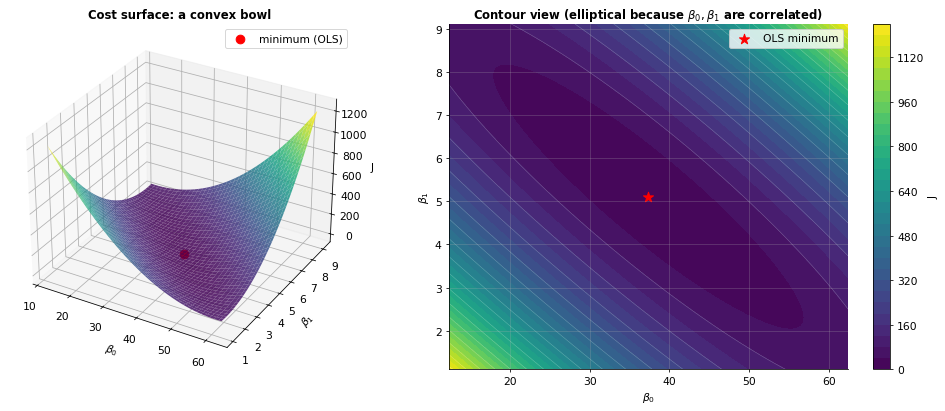

In [7]:
b0g = np.linspace(b0_hat - 25, b0_hat + 25, 120)
b1g = np.linspace(b1_hat - 4, b1_hat + 4, 120)
B0, B1 = np.meshgrid(b0g, b1g)
J = np.array([[np.mean((y - (a + b * x))**2) / 2 for a in b0g] for b in b1g])   # J = 1/(2n) * SSE

fig = plt.figure(figsize=(15, 6))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(B0, B1, J, cmap="viridis", alpha=.85, linewidth=0)
ax.scatter([b0_hat], [b1_hat], [J.min()], color="red", s=80, label="minimum (OLS)")
ax.set(xlabel=r"$\beta_0$", ylabel=r"$\beta_1$", zlabel="J", title="Cost surface: a convex bowl"); ax.legend()

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contourf(B0, B1, J, levels=30, cmap="viridis")
ax2.contour(B0, B1, J, levels=15, colors="white", alpha=.3, linewidths=.5)
ax2.scatter([b0_hat], [b1_hat], color="red", s=120, marker="*", label="OLS minimum")
ax2.set(xlabel=r"$\beta_0$", ylabel=r"$\beta_1$", title="Contour view (elliptical because $\\beta_0,\\beta_1$ are correlated)"); ax2.legend()
plt.colorbar(cs, ax=ax2, label="J"); plt.tight_layout(); plt.show()

The **tilted ellipses** show that $\hat\beta_0$ and $\hat\beta_1$ trade off against each other: a steeper slope must be compensated by a lower intercept. That's why gradient descent on *unscaled* features crawls down a narrow valley (Section 3.4).

### 2.8 Outlier sensitivity: MSE vs MAE vs Huber
Add two bad points (a "high-scorer" recorded as 15 by mistake) and see which loss resists.

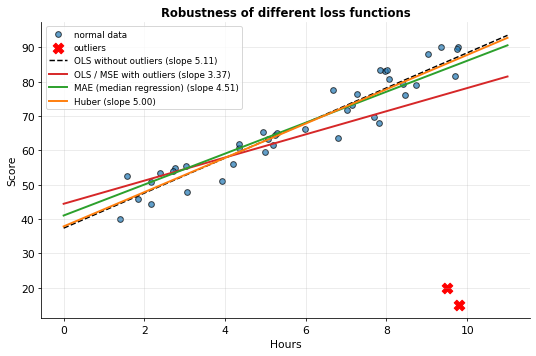

In [8]:
from scipy.optimize import minimize
from sklearn.linear_model import HuberRegressor

x_o = np.append(x, [9.5, 9.8]); y_o = np.append(y, [20, 15])          # two outliers at high x

b1_ols, b0_ols = np.polyfit(x_o, y_o, 1)
mae_obj = lambda b: np.mean(np.abs(y_o - (b[0] + b[1] * x_o)))
b_mae = minimize(mae_obj, [b0_ols, b1_ols], method="Nelder-Mead").x
hub = HuberRegressor(epsilon=1.35).fit(x_o.reshape(-1, 1), y_o)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(x, y, s=35, edgecolor="k", alpha=.7, label="normal data")
ax.scatter(x_o[-2:], y_o[-2:], s=120, color="red", marker="X", label="outliers")
ax.plot(xs, b0_hat + b1_hat * xs, "k--", label=f"OLS without outliers (slope {b1_hat:.2f})")
ax.plot(xs, b0_ols + b1_ols * xs, "tab:red", lw=2, label=f"OLS / MSE with outliers (slope {b1_ols:.2f})")
ax.plot(xs, b_mae[0] + b_mae[1] * xs, "tab:green", lw=2, label=f"MAE (median regression) (slope {b_mae[1]:.2f})")
ax.plot(xs, hub.intercept_ + hub.coef_[0] * xs, "tab:orange", lw=2, label=f"Huber (slope {hub.coef_[0]:.2f})")
ax.set(xlabel="Hours", ylabel="Score", title="Robustness of different loss functions"); ax.legend(fontsize=9)
plt.show()

**Lesson:** squared error gets dragged toward outliers; MAE and Huber stay close to the true trend. Always *look at your data* and choose the loss that matches your problem (e.g. if a 10-unit error is **more than twice as bad** as a 5-unit error, squared loss is appropriate).

## 3. Finding the Best Coefficients

We want $\hat{\boldsymbol\beta}=\arg\min_{\boldsymbol\beta}\ \text{SSE}(\boldsymbol\beta)$. Four ways to get there:

1. Calculus, simple regression → closed-form formulas
2. Calculus, matrix form → **Normal Equation**
3. Geometry → **orthogonal projection**
4. Iterative → **Gradient Descent** (needed when data is huge or the model has no closed form)

### 3.1 Calculus for simple regression
$$
S(\beta_0,\beta_1)=\sum_{i}(y_i-\beta_0-\beta_1x_i)^2
$$
Set both partial derivatives to zero:

$$
\frac{\partial S}{\partial\beta_0}=-2\sum(y_i-\beta_0-\beta_1x_i)=0 \;\Rightarrow\; \boxed{\hat\beta_0=\bar y-\hat\beta_1\bar x}
$$
$$
\frac{\partial S}{\partial\beta_1}=-2\sum x_i(y_i-\beta_0-\beta_1x_i)=0
\;\Rightarrow\;
\boxed{\hat\beta_1=\frac{\sum(x_i-\bar x)(y_i-\bar y)}{\sum(x_i-\bar x)^2}=\frac{S_{xy}}{S_{xx}}=r_{xy}\,\frac{s_y}{s_x}}
$$

**Intuition**
* $\hat\beta_0=\bar y-\hat\beta_1\bar x$ ⇒ *the least-squares line always passes through the centroid $(\bar x,\bar y)$*.
* $\hat\beta_1=r\,s_y/s_x$ ⇒ the slope is the **correlation** rescaled to the units of $y$ per unit of $x$. If $x$ and $y$ are uncorrelated, the slope is 0.

In [9]:
x = df_study["hours"].values; y = df_study["score"].values
Sxx = np.sum((x - x.mean())**2)
Sxy = np.sum((x - x.mean()) * (y - y.mean()))
b1 = Sxy / Sxx
b0 = y.mean() - b1 * x.mean()
r_xy = np.corrcoef(x, y)[0, 1]

print(f"Closed form   : b0 = {b0:.4f}, b1 = {b1:.4f}")
print(f"np.polyfit    : b0 = {np.polyfit(x, y, 1)[1]:.4f}, b1 = {np.polyfit(x, y, 1)[0]:.4f}")
print(f"r * sy/sx     : b1 = {r_xy * y.std() / x.std():.4f}   (r = {r_xy:.4f})")
print(f"Passes through centroid? predicted at x̄ = {b0 + b1 * x.mean():.4f}  vs  ȳ = {y.mean():.4f}")
print("True (hidden) values: b0 = 35, b1 = 5.5  → our estimates are close, but not identical (sampling noise!)")

Closed form   : b0 = 37.3518, b1 = 5.1083
np.polyfit    : b0 = 37.3518, b1 = 5.1083
r * sy/sx     : b1 = 5.1083   (r = 0.9524)
Passes through centroid? predicted at x̄ = 66.9924  vs  ȳ = 66.9924
True (hidden) values: b0 = 35, b1 = 5.5  → our estimates are close, but not identical (sampling noise!)


### 3.2 Matrix form → the Normal Equation

Stack the data: $\mathbf y\in\mathbb R^{n}$, $\mathbf X\in\mathbb R^{n\times(p+1)}$ (first column of ones for the intercept), $\boldsymbol\beta\in\mathbb R^{p+1}$.

$$
S(\boldsymbol\beta)=(\mathbf y-\mathbf X\boldsymbol\beta)^\top(\mathbf y-\mathbf X\boldsymbol\beta)
=\mathbf y^\top\mathbf y-2\boldsymbol\beta^\top\mathbf X^\top\mathbf y+\boldsymbol\beta^\top\mathbf X^\top\mathbf X\boldsymbol\beta
$$

Gradient and Hessian:
$$
\nabla_{\boldsymbol\beta}S=-2\mathbf X^\top\mathbf y+2\mathbf X^\top\mathbf X\boldsymbol\beta=\mathbf 0
\;\Longrightarrow\;
\boxed{\mathbf X^\top\mathbf X\,\hat{\boldsymbol\beta}=\mathbf X^\top\mathbf y}
\;\Longrightarrow\;
\hat{\boldsymbol\beta}=(\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top\mathbf y
$$
$$
\nabla^2 S=2\mathbf X^\top\mathbf X\succeq0 \;\Rightarrow\; \text{convex, so this stationary point is the global minimum.}
$$

**Conditions:** $\mathbf X^\top\mathbf X$ must be invertible ⇔ the columns of $\mathbf X$ are linearly independent (no *perfect multicollinearity*) and $n>p$.

**Numerical note:** in practice we *don't* invert $\mathbf X^\top\mathbf X$ (it squares the condition number). Libraries use **QR** or **SVD** factorisations (`np.linalg.lstsq`, `scikit-learn`, `statsmodels` via pseudo-inverse).

In [10]:
X = np.c_[np.ones(len(x)), x]                       # design matrix [1, x]

beta_inv   = np.linalg.inv(X.T @ X) @ X.T @ y       # textbook formula (fine for teaching)
beta_solve = np.linalg.solve(X.T @ X, X.T @ y)      # better: solve the linear system
beta_lstsq = np.linalg.lstsq(X, y, rcond=None)[0]   # best: SVD-based least squares
beta_pinv  = np.linalg.pinv(X) @ y                  # Moore-Penrose pseudo-inverse

print(pd.DataFrame([beta_inv, beta_solve, beta_lstsq, beta_pinv], columns=["b0", "b1"],
                   index=["inverse", "solve", "lstsq (SVD)", "pinv"]))
print("\nCondition number of X'X :", f"{np.linalg.cond(X.T @ X):,.1f}", "  vs  of X :", f"{np.linalg.cond(X):,.1f}  (X'X squares it!)")

                 b0     b1
inverse     37.3518 5.1083
solve       37.3518 5.1083
lstsq (SVD) 37.3518 5.1083
pinv        37.3518 5.1083

Condition number of X'X : 255.8   vs  of X : 16.0  (X'X squares it!)


### 3.3 Geometric view: OLS is an *orthogonal projection*

Think of $\mathbf y$ as a **vector in $n$-dimensional space**. All predictions $\mathbf X\boldsymbol\beta$ live in the **column space** of $\mathbf X$ (a flat subspace). The best prediction $\hat{\mathbf y}$ is the point in that subspace **closest** to $\mathbf y$ — which is the *perpendicular projection*:

$$
\hat{\mathbf y}=\mathbf H\mathbf y,\qquad \mathbf H=\mathbf X(\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top\ \ (\text{"hat matrix"})
$$

The residual vector $\mathbf e=\mathbf y-\hat{\mathbf y}$ is **perpendicular** to every column of $\mathbf X$:  $\ \mathbf X^\top\mathbf e=\mathbf 0$. Two direct consequences: residuals sum to zero (the column of ones) and residuals are uncorrelated with every predictor. This right-angle also gives Pythagoras: $\|\mathbf y\|^2=\|\hat{\mathbf y}\|^2+\|\mathbf e\|^2$ — the SST = SSR + SSE identity.

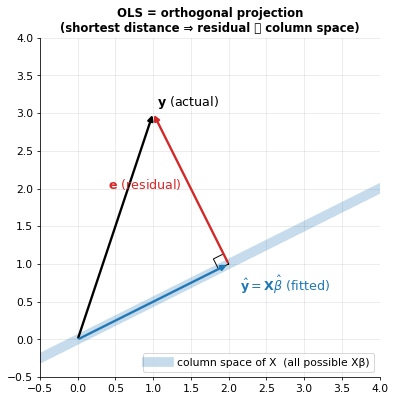

X'e  (should be ~0)              : [-0. -0.]
Trace of H = number of params    : 2.0
H is idempotent (H@H == H)?      : True
Pythagoras: |y|² = |ŷ|² + |e|²   : 187122.695 = 187122.695


In [11]:
# 2-D cartoon: one column of X spans a line; y is projected onto it
a = np.array([2.0, 1.0]); yv = np.array([1.0, 3.0])
proj = (a @ yv) / (a @ a) * a
ev = yv - proj

fig, ax = plt.subplots(figsize=(6.8, 6.3))
t = np.array([-0.5, 4]); ax.plot(t * a[0], t * a[1], color="tab:blue", alpha=.25, lw=10, label="column space of X  (all possible Xβ)")
arrow = lambda p, q, c, lab: ax.annotate("", xy=q, xytext=p, arrowprops=dict(arrowstyle="-|>", lw=2.4, color=c))
arrow((0, 0), yv, "k", "y");           ax.text(*(yv + [0.05, 0.1]), r"$\mathbf{y}$ (actual)", fontsize=13)
arrow((0, 0), proj, "tab:blue", "");    ax.text(*(proj + [0.15, -0.35]), r"$\hat{\mathbf{y}}=\mathbf{X}\hat\beta$ (fitted)", fontsize=13, color="tab:blue")
arrow(proj, yv, "tab:red", "");         ax.text(*(proj + ev / 2 + [-1.1, 0]), r"$\mathbf{e}$ (residual)", fontsize=13, color="tab:red")
u, v = a / np.linalg.norm(a), ev / np.linalg.norm(ev); s = .15                      # right-angle mark
sq = np.array([proj, proj - s * u, proj - s * u + s * v, proj + s * v, proj]); ax.plot(sq[:, 0], sq[:, 1], "k", lw=1)
ax.set(xlim=(-0.5, 4), ylim=(-0.5, 4), aspect="equal", title="OLS = orthogonal projection\n(shortest distance ⇒ residual ⟂ column space)"); ax.legend(loc="lower right")
plt.show()

# Numerical verification on our real data
H = X @ np.linalg.inv(X.T @ X) @ X.T
e = y - H @ y
print("X'e  (should be ~0)              :", np.round(X.T @ e, 8))
print("Trace of H = number of params    :", round(np.trace(H), 6))
print("H is idempotent (H@H == H)?      :", np.allclose(H @ H, H))
print("Pythagoras: |y|² = |ŷ|² + |e|²   :", round(y @ y, 3), "=", round((H @ y) @ (H @ y) + e @ e, 3))

### 3.4 Gradient Descent (GD)

When $p$ is huge (millions of features), $n$ is enormous, or the model is not linear, we can't solve a linear system, so we **walk downhill** on the cost surface:

$$
J(\boldsymbol\theta)=\frac1{2n}\|\mathbf X\boldsymbol\theta-\mathbf y\|^2,\qquad
\nabla J=\frac1n\mathbf X^\top(\mathbf X\boldsymbol\theta-\mathbf y)
$$
$$
\boxed{\boldsymbol\theta_{t+1}=\boldsymbol\theta_t-\eta\,\nabla J(\boldsymbol\theta_t)}
$$

* $\eta$ = **learning rate**. Too small ⇒ painfully slow; too large ⇒ overshoots and **diverges**.
* For this quadratic cost the Hessian is $\mathbf H_J=\mathbf X^\top\mathbf X/n$. GD converges iff $\eta<2/\lambda_{max}$, and the speed is governed by the **condition number** $\lambda_{max}/\lambda_{min}$ — that's why we **standardise features** first (makes the contours circular).

Per-parameter update (what the gradient actually looks like):
$$
\theta_j\leftarrow\theta_j-\eta\cdot\frac1n\sum_i (\hat y_i-y_i)\,x_{ij}
$$

GD  (η=0.1, 300 iters): b0 = 37.3518, b1 = 5.1083
OLS closed form       : b0 = 37.3518, b1 = 5.1083


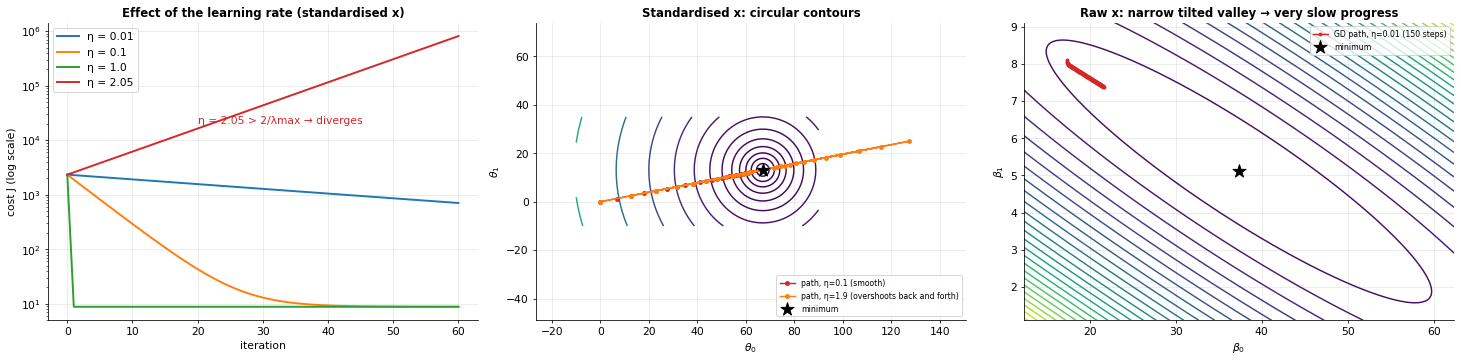

In [12]:
def gradient_descent(X, y, lr=0.1, epochs=100, theta0=None):
    n = len(y)
    theta = np.zeros(X.shape[1]) if theta0 is None else np.array(theta0, float)
    th_hist, cost_hist = [theta.copy()], []
    for _ in range(epochs):
        err = X @ theta - y
        cost_hist.append(err @ err / (2 * n))
        theta = theta - lr * (X.T @ err) / n
        th_hist.append(theta.copy())
    cost_hist.append(((X @ theta - y)**2).sum() / (2 * n))
    return theta, np.array(th_hist), np.array(cost_hist)

# Standardise x  (z = (x-mean)/sd) so that GD behaves well
mu, sd = x.mean(), x.std()
Xz = np.c_[np.ones(len(x)), (x - mu) / sd]

lrs = [0.01, 0.1, 1.0, 2.05]
fig, ax = plt.subplots(1, 3, figsize=(21, 5.3))
for lr in lrs:
    th, hist, cost = gradient_descent(Xz, y, lr=lr, epochs=60)
    ax[0].semilogy(cost, label=f"η = {lr}", lw=2)
ax[0].set(xlabel="iteration", ylabel="cost J (log scale)", title="Effect of the learning rate (standardised x)"); ax[0].legend()
ax[0].text(20, 2e4, "η = 2.05 > 2/λmax → diverges", color="tab:red")

# recover coefficients in original units:  y = th0 + th1*(x-mu)/sd  →  b1 = th1/sd, b0 = th0 - th1*mu/sd
th, hist, cost = gradient_descent(Xz, y, lr=0.1, epochs=300)
b1_gd, b0_gd = th[1] / sd, th[0] - th[1] * mu / sd
print(f"GD  (η=0.1, 300 iters): b0 = {b0_gd:.4f}, b1 = {b1_gd:.4f}")
print(f"OLS closed form       : b0 = {b0:.4f}, b1 = {b1:.4f}")

# Contour + paths in STANDARDISED space (contours are circles → gradient points straight at the minimum)
g0 = np.linspace(-10, 90, 150); g1 = np.linspace(-10, 35, 150)
G0, G1 = np.meshgrid(g0, g1)
JZ = np.array([[np.mean((y - (a + b * Xz[:, 1]))**2) / 2 for a in g0] for b in g1])
ax[1].contour(G0, G1, JZ, levels=np.logspace(0, 3.7, 18), cmap="viridis")
for lr, c in [(0.1, "tab:red"), (1.9, "tab:orange")]:
    _, h, _ = gradient_descent(Xz, y, lr=lr, epochs=25)
    ax[1].plot(h[:, 0], h[:, 1], "o-", color=c, ms=4, label=f"path, η={lr}" + (" (overshoots back and forth)" if lr > 1 else " (smooth)"))
ax[1].scatter(*th, marker="*", s=200, color="k", zorder=5, label="minimum")
ax[1].set_aspect("equal", adjustable="datalim")
ax[1].set(xlabel=r"$\theta_0$", ylabel=r"$\theta_1$", title="Standardised x: circular contours"); ax[1].legend(fontsize=8, loc="lower right")

# Same algorithm on the RAW (unscaled) parameters: elongated valley → slow zig-zag
_, h_raw, _ = gradient_descent(X, y, lr=0.01, epochs=150, theta0=[b0_hat - 20, b1_hat + 3])
ax[2].contour(B0, B1, J, levels=25, cmap="viridis")
ax[2].plot(h_raw[:, 0], h_raw[:, 1], "o-", color="tab:red", ms=3, label="GD path, η=0.01 (150 steps)")
ax[2].scatter(b0_hat, b1_hat, marker="*", s=200, color="k", zorder=5, label="minimum")
ax[2].set(xlabel=r"$\beta_0$", ylabel=r"$\beta_1$", title="Raw x: narrow tilted valley → very slow progress"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Feature scaling matters.** Compare GD with the *same* learning rate on raw vs. standardised $x$:

Condition number of X'X/n  raw: 255.8   standardised: 1.0


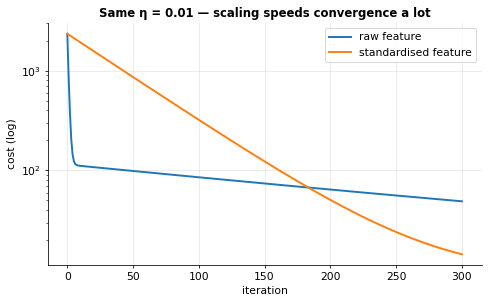

In [13]:
_, _, cost_scaled = gradient_descent(Xz, y, lr=0.01, epochs=300)
_, _, cost_raw    = gradient_descent(X,  y, lr=0.01, epochs=300)      # raw hours (1..10)
print("Condition number of X'X/n  raw:", f"{np.linalg.cond(X.T @ X / len(y)):.1f}", "  standardised:", f"{np.linalg.cond(Xz.T @ Xz / len(y)):.1f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(cost_raw, label="raw feature", lw=2); ax.semilogy(cost_scaled, label="standardised feature", lw=2)
ax.set(xlabel="iteration", ylabel="cost (log)", title="Same η = 0.01 — scaling speeds convergence a lot"); ax.legend(); plt.show()

### 3.5 Stochastic & mini-batch gradient descent
Instead of using all $n$ rows for each step, use **one** row (SGD) or a **small batch** (mini-batch). Each step is noisy but *much cheaper*, and it is how deep-learning models are trained.

| Variant | Rows per update | Path | Cost per epoch |
|---|---|---|---|
| Batch GD | all $n$ | smooth | 1 update |
| Mini-batch GD | e.g. 8–256 | slightly noisy | $n/b$ updates |
| SGD | 1 | very noisy | $n$ updates |

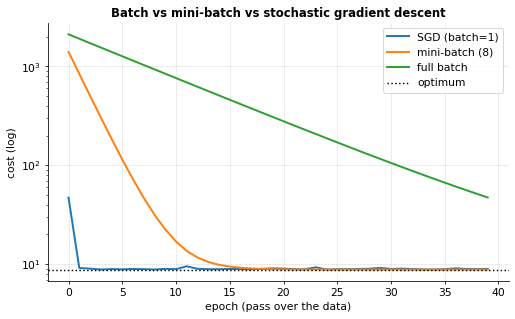

In [14]:
def sgd(X, y, lr=0.05, epochs=40, batch=1, seed=0):
    rng = np.random.default_rng(seed); n = len(y)
    theta = np.zeros(X.shape[1]); costs = []
    for _ in range(epochs):
        idx = rng.permutation(n)
        for s in range(0, n, batch):
            b = idx[s:s + batch]
            theta -= lr * X[b].T @ (X[b] @ theta - y[b]) / len(b)
        costs.append(((X @ theta - y)**2).sum() / (2 * n))
    return theta, np.array(costs)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for b, lab in [(1, "SGD (batch=1)"), (8, "mini-batch (8)"), (len(y), "full batch")]:
    _, c = sgd(Xz, y, lr=0.05, epochs=40, batch=b)
    ax.semilogy(c, lw=2, label=lab)
ax.axhline(cost.min(), color="k", ls=":", label="optimum")
ax.set(xlabel="epoch (pass over the data)", ylabel="cost (log)", title="Batch vs mini-batch vs stochastic gradient descent"); ax.legend(); plt.show()

## 4. Statistical Inference — *How sure are we?*

Getting $\hat\beta$ is only half the story. Because our data is a random sample, $\hat\beta$ would change with a new sample. Inference quantifies that uncertainty.

### 4.1 Distribution of the estimator
Under the classical assumptions ($\boldsymbol\varepsilon\sim\mathcal N(\mathbf 0,\sigma^2\mathbf I)$):

$$
\hat{\boldsymbol\beta}\sim\mathcal N\!\big(\boldsymbol\beta,\ \sigma^2(\mathbf X^\top\mathbf X)^{-1}\big),\qquad
\hat\sigma^2=s^2=\frac{\text{SSE}}{n-p-1}
$$
(we divide by $n-p-1$ = *residual degrees of freedom*, because $p+1$ parameters were estimated from the data — this makes $s^2$ unbiased).

* **Standard error:** $\text{SE}(\hat\beta_j)=\sqrt{s^2\,[(\mathbf X^\top\mathbf X)^{-1}]_{jj}}$. For simple regression $\text{SE}(\hat\beta_1)=s/\sqrt{S_{xx}}$ → *more spread in $x$, more data, less noise ⇒ more precise slope.*
* **t-test** for $H_0:\beta_j=0$: $\ t_j=\dfrac{\hat\beta_j}{\text{SE}(\hat\beta_j)}\sim t_{n-p-1}$. The **p-value** is the probability of a $|t|$ at least this large if the true coefficient were 0.
* **Confidence interval:** $\hat\beta_j\pm t_{1-\alpha/2,\,n-p-1}\cdot\text{SE}(\hat\beta_j)$.
* **F-test** (is the model useful *at all*?), $H_0:\beta_1=\dots=\beta_p=0$:
$$F=\frac{\text{SSR}/p}{\text{SSE}/(n-p-1)}\sim F_{p,\,n-p-1}$$
* **Information criteria** (for comparing models; *lower is better*): with $k=p+1$ parameters and Gaussian log-likelihood $\ell=-\frac n2[\ln(2\pi)+\ln(\text{SSE}/n)+1]$
$$\text{AIC}=2k-2\ell,\qquad \text{BIC}=k\ln n-2\ell$$
BIC penalises complexity more strongly than AIC.

Let's compute the full regression table **by hand**. In Section 7 we'll confirm that statsmodels gives identical numbers.

In [15]:
n = len(y); X = np.c_[np.ones(n), x]; p = 1
beta = np.linalg.solve(X.T @ X, X.T @ y)
resid = y - X @ beta
df_resid = n - p - 1
SSE = resid @ resid; SST = ((y - y.mean())**2).sum(); SSR = SST - SSE
s2 = SSE / df_resid
cov = s2 * np.linalg.inv(X.T @ X)
se = np.sqrt(np.diag(cov))
t_vals = beta / se
p_vals = 2 * stats.t.sf(np.abs(t_vals), df_resid)
t_crit = stats.t.ppf(0.975, df_resid)
ci_lo, ci_hi = beta - t_crit * se, beta + t_crit * se

coef_table = pd.DataFrame({"coef": beta, "std err": se, "t": t_vals, "P>|t|": p_vals, "[0.025": ci_lo, "0.975]": ci_hi}, index=["const", "hours"])
display(coef_table)

F = (SSR / p) / (SSE / df_resid); pF = stats.f.sf(F, p, df_resid)
llf = -n / 2 * (np.log(2 * np.pi) + np.log(SSE / n) + 1)
k = p + 1
summary_by_hand = pd.Series({"R²": SSR / SST, "Adj R²": 1 - (1 - SSR / SST) * (n - 1) / df_resid, "Residual std error (s)": np.sqrt(s2),
                             "F-statistic": F, "Prob(F)": pF, "Log-Likelihood": llf, "AIC": 2 * k - 2 * llf, "BIC": k * np.log(n) - 2 * llf})
display(summary_by_hand.to_frame("by hand"))

,coef,std err,t,P>|t|,[0.025,0.975]
const,37.3518,1.6837,22.1844,0.0000,33.9433,40.7602
hours,5.1083,0.2653,19.2546,0.0000,4.5712,5.6454


,by hand
R²,0.9070
Adj R²,0.9046
Residual std error (s),4.3131
F-statistic,370.7383
Prob(F),0.0000
Log-Likelihood,-114.1975
AIC,232.3950
BIC,235.7728


### 4.2 Pictures of the variance decomposition and the t-test

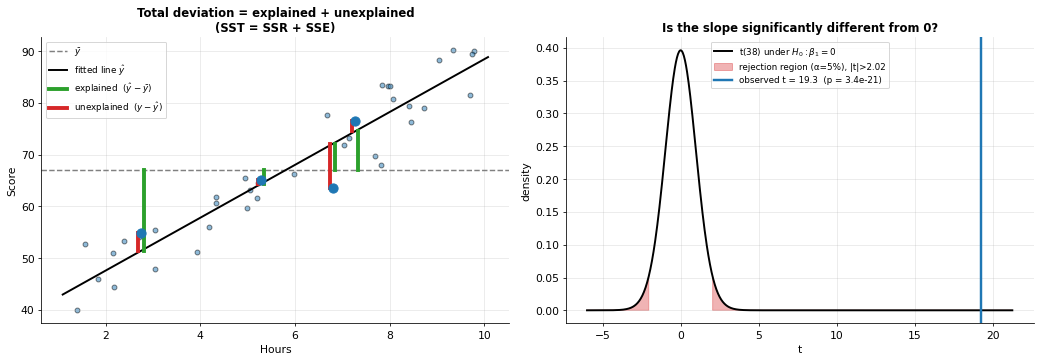

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5.3))

# --- Left: decomposition of deviation for 4 points
pick = [3, 12, 25, 37]
ax[0].scatter(x, y, s=25, alpha=.5, edgecolor="k")
ax[0].axhline(y.mean(), color="grey", ls="--", label=r"$\bar y$")
xs_ = np.linspace(x.min() - .3, x.max() + .3, 50); ax[0].plot(xs_, beta[0] + beta[1] * xs_, "k", lw=2, label=r"fitted line $\hat y$")
for j, i in enumerate(pick):
    yh = beta[0] + beta[1] * x[i]
    ax[0].plot([x[i] + .06, x[i] + .06], [y.mean(), yh], color="tab:green", lw=4, label="explained  ($\\hat y-\\bar y$)" if j == 0 else None)
    ax[0].plot([x[i] - .06, x[i] - .06], [yh, y[i]], color="tab:red", lw=4, label="unexplained  ($y-\\hat y$)" if j == 0 else None)
    ax[0].scatter(x[i], y[i], s=90, color="tab:blue", zorder=5)
ax[0].set(xlabel="Hours", ylabel="Score", title="Total deviation = explained + unexplained\n(SST = SSR + SSE)"); ax[0].legend(fontsize=9)

# --- Right: t-distribution and the observed slope t-stat
tt = np.linspace(-6, max(abs(t_vals[1]) + 2, 8), 800)
ax[1].plot(tt, stats.t.pdf(tt, df_resid), "k", lw=2, label=f"t({df_resid}) under $H_0:\\beta_1=0$")
ax[1].fill_between(tt, stats.t.pdf(tt, df_resid), where=np.abs(tt) >= t_crit, color="tab:red", alpha=.35, label=f"rejection region (α=5%), |t|>{t_crit:.2f}")
ax[1].axvline(t_vals[1], color="tab:blue", lw=2.5, label=f"observed t = {t_vals[1]:.1f}  (p = {p_vals[1]:.1e})")
ax[1].set(xlabel="t", ylabel="density", title="Is the slope significantly different from 0?"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

### 4.3 Confidence interval vs. Prediction interval (very commonly confused!)

For a new value $x_0$:

| | Question answered | Formula (half-width) |
|---|---|---|
| **Confidence interval (CI) for the mean** | "Where is the *average* score of everyone who studies $x_0$ hours?" | $t\cdot s\sqrt{\dfrac1n+\dfrac{(x_0-\bar x)^2}{S_{xx}}}$ |
| **Prediction interval (PI)** | "Where will *one new student's* score fall?" | $t\cdot s\sqrt{\mathbf{1}+\dfrac1n+\dfrac{(x_0-\bar x)^2}{S_{xx}}}$ |

The extra "1" is the irreducible noise $\sigma^2$ of an individual observation, so **PI is always wider**. Both are narrowest at $x_0=\bar x$ and fan out toward the edges (uncertainty about the slope is amplified far from the centre of the data).

Share of observed points inside the 95% prediction band: 98%  (expect ≈ 95%)


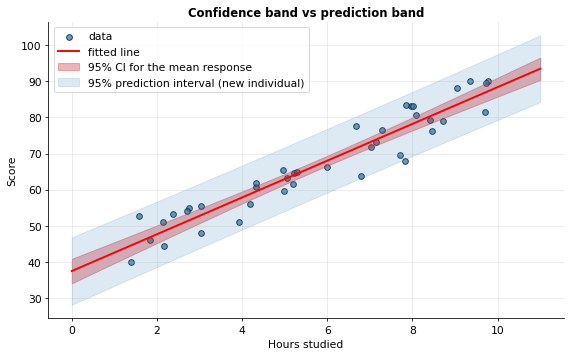

In [17]:
x0 = np.linspace(0, 11, 200)
fit0 = beta[0] + beta[1] * x0
lever = 1 / n + (x0 - x.mean())**2 / Sxx
ci_half = t_crit * np.sqrt(s2 * lever)
pi_half = t_crit * np.sqrt(s2 * (1 + lever))

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.scatter(x, y, s=35, edgecolor="k", alpha=.7, label="data")
ax.plot(x0, fit0, "r", lw=2, label="fitted line")
ax.fill_between(x0, fit0 - ci_half, fit0 + ci_half, color="tab:red", alpha=.35, label="95% CI for the mean response")
ax.fill_between(x0, fit0 - pi_half, fit0 + pi_half, color="tab:blue", alpha=.15, label="95% prediction interval (new individual)")
ax.set(xlabel="Hours studied", ylabel="Score", title="Confidence band vs prediction band"); ax.legend(loc="upper left")
inside = np.mean(np.abs(y - (beta[0] + beta[1] * x)) <= t_crit * np.sqrt(s2 * (1 + 1 / n + (x - x.mean())**2 / Sxx)))
print(f"Share of observed points inside the 95% prediction band: {inside:.0%}  (expect ≈ 95%)")
plt.show()

## 5. Multiple Linear Regression

With $p$ predictors the model is $\mathbf y=\mathbf X\boldsymbol\beta+\boldsymbol\varepsilon$ and **everything from Section 3–4 carries over unchanged** — the Normal Equation, $\text{Cov}(\hat{\boldsymbol\beta})=\sigma^2(\mathbf X^\top\mathbf X)^{-1}$, t-tests, F-test.

### 5.1 Interpretation: "holding the others constant"
$\beta_j$ = expected change in $y$ for a one-unit increase in $x_j$ **while all other predictors stay fixed**.

The **Frisch–Waugh–Lovell theorem** makes this literal: $\hat\beta_1$ from the full regression equals the slope you get by
1. regressing $y$ on the *other* predictors and keeping the residuals ($\tilde y$),
2. regressing $x_1$ on the *other* predictors and keeping the residuals ($\tilde x_1$),
3. regressing $\tilde y$ on $\tilde x_1$.

I.e. each coefficient measures the effect of the part of $x_j$ that is **not explained by the other variables**.

         true  estimated
const  3.0000     2.8543
x1     2.0000     1.8557
x2    -1.5000    -1.4389
x3     0.5000     0.5179

FWL slope of x1 = 1.855747   |   full-regression coefficient of x1 = 1.855747


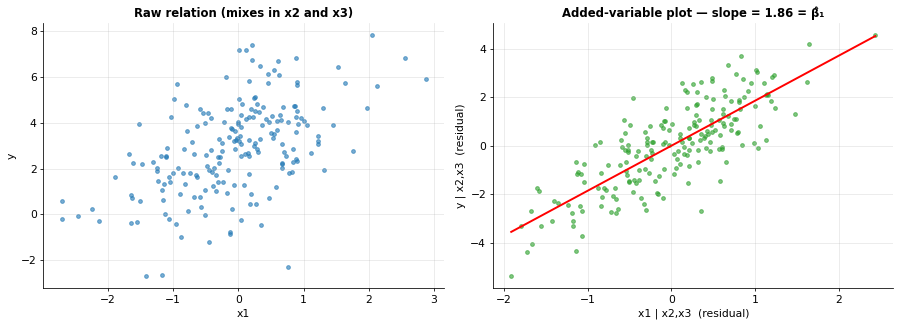

In [18]:
rng = np.random.default_rng(1)
N = 200
x1 = rng.normal(size=N)
x2 = 0.5 * x1 + np.sqrt(1 - 0.25) * rng.normal(size=N)         # corr(x1,x2) = 0.5
x3 = rng.normal(size=N)
y_m = 3 + 2 * x1 - 1.5 * x2 + 0.5 * x3 + rng.normal(0, 1, N)     # true: 3, 2, -1.5, 0.5
df_m = pd.DataFrame({"x1": x1, "x2": x2, "x3": x3, "y": y_m})

X_m = np.c_[np.ones(N), x1, x2, x3]
beta_m = np.linalg.lstsq(X_m, y_m, rcond=None)[0]
print(pd.DataFrame({"true": [3, 2, -1.5, 0.5], "estimated": beta_m}, index=["const", "x1", "x2", "x3"]))

# Frisch–Waugh–Lovell: effect of x1 after removing the influence of x2, x3
Z = np.c_[np.ones(N), x2, x3]
resid_of = lambda target: target - Z @ np.linalg.lstsq(Z, target, rcond=None)[0]
y_tilde, x1_tilde = resid_of(y_m), resid_of(x1)
slope_fwl = (x1_tilde @ y_tilde) / (x1_tilde @ x1_tilde)
print(f"\nFWL slope of x1 = {slope_fwl:.6f}   |   full-regression coefficient of x1 = {beta_m[1]:.6f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].scatter(x1, y_m, s=15, alpha=.6); ax[0].set(xlabel="x1", ylabel="y", title="Raw relation (mixes in x2 and x3)")
ax[1].scatter(x1_tilde, y_tilde, s=15, alpha=.6, color="tab:green")
g = np.linspace(x1_tilde.min(), x1_tilde.max(), 10); ax[1].plot(g, slope_fwl * g, "r", lw=2)
ax[1].set(xlabel="x1 | x2,x3  (residual)", ylabel="y | x2,x3  (residual)", title=f"Added-variable plot — slope = {slope_fwl:.2f} = β̂₁")
plt.tight_layout(); plt.show()

### 5.2 Multicollinearity — when predictors overlap
If $x_2\approx x_1$, the model can't tell *which* variable deserves the credit. Predictions stay fine, but individual coefficients become **unstable with huge standard errors**:

$$
\text{Var}(\hat\beta_j)=\frac{\sigma^2}{(n-1)\,\text{Var}(x_j)}\cdot\underbrace{\frac1{1-R_j^2}}_{\text{VIF}_j}
$$

where $R_j^2$ comes from regressing $x_j$ on the *other* predictors. **VIF (Variance Inflation Factor)** tells how many times the variance is inflated. Rule of thumb: VIF > 5 (worry), > 10 (serious). With perfect collinearity $R_j^2=1$, VIF $=\infty$ and $\mathbf X^\top\mathbf X$ is singular.

**Experiment:** repeat the same study 400 times at three correlation levels between $x_1$ and $x_2$ (true $\beta_1=2$).

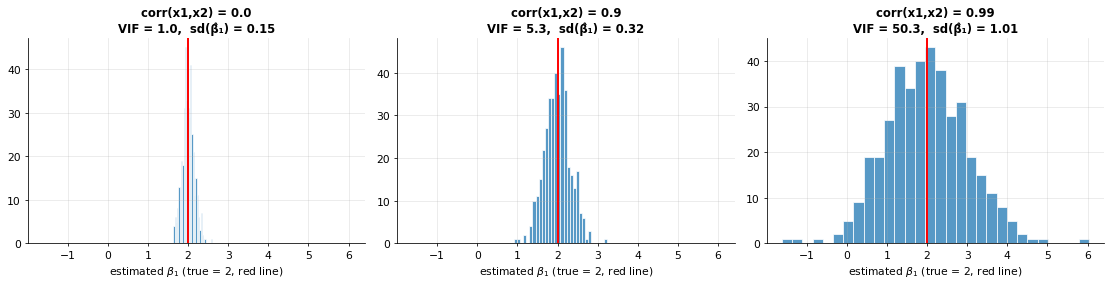

In [19]:
def simulate_beta1(rho, reps=400, n=50, seed=0):
    rng = np.random.default_rng(seed); out = []
    for _ in range(reps):
        a = rng.normal(size=n); b = rho * a + np.sqrt(1 - rho**2) * rng.normal(size=n)
        yy = 1 + 2 * a + 2 * b + rng.normal(0, 1, n)
        out.append(np.linalg.lstsq(np.c_[np.ones(n), a, b], yy, rcond=None)[0][1])
    return np.array(out)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2), sharex=True)
for a_, rho in zip(ax, [0.0, 0.9, 0.99]):
    est = simulate_beta1(rho)
    a_.hist(est, bins=30, color="tab:blue", alpha=.75, edgecolor="w"); a_.axvline(2, color="r", lw=2)
    a_.set(title=f"corr(x1,x2) = {rho}\nVIF = {1 / (1 - rho**2):.1f},  sd(β̂₁) = {est.std():.2f}", xlabel=r"estimated $\beta_1$ (true = 2, red line)")
plt.tight_layout(); plt.show()

The estimates are still *unbiased* (centred on 2), but the spread explodes. **Remedies:** drop/merge redundant variables, combine them (e.g. average, PCA), or use **Ridge regression** (Section 9).

### 5.3 Categorical predictors & interactions (quick reference)
* **Dummy (one-hot) encoding:** a category with $k$ levels becomes $k-1$ 0/1 columns; the omitted level is the *baseline*. (Using all $k$ plus an intercept ⇒ perfect collinearity — the "dummy-variable trap".) Each dummy's $\beta$ = average difference from the baseline, holding others fixed.
* **Interaction** $x_1x_2$: lets the effect of $x_1$ depend on $x_2$: $\ \partial y/\partial x_1=\beta_1+\beta_{12}x_2$.
* **Transformations** ($\log y$, $x^2$, $\sqrt x$) keep the model linear in $\beta$ while modelling curvature or fixing skewness/heteroscedasticity. In a **log-linear** model $\ln y=\beta_0+\beta_1x$, a one-unit rise in $x$ multiplies $y$ by $e^{\beta_1}\approx1+\beta_1$ (a *percentage* effect).

## 6. Assumptions & Diagnostics — *Can we trust the numbers?*

The Gauss–Markov / classical assumptions (remember **L-I-N-E** plus one):

| | Assumption | If violated | How to check | Typical fix |
|---|---|---|---|---|
| **L** | **Linearity** – $E[y|x]$ is linear in the parameters | biased, wrong predictions | Residuals vs fitted (should be a flat, patternless cloud) | add polynomial/interaction terms, transform variables |
| **I** | **Independence** of errors | SEs too small, false significance | Durbin–Watson, residuals vs time | time-series models, cluster-robust SEs |
| **N** | **Normality** of errors *(only needed for exact small-sample t/F/CI)* | inference inaccurate for small $n$ | Q–Q plot, Shapiro–Wilk, Jarque–Bera | transform $y$, more data (CLT rescues large $n$) |
| **E** | **Equal variance** (homoscedasticity) | SEs wrong (estimates still unbiased) | Residuals vs fitted (funnel?), Breusch–Pagan | log-transform $y$, WLS, robust (HC) SEs |
| + | **No perfect multicollinearity**, exogeneity ($E[\varepsilon|X]=0$) | unstable / biased coefficients | VIF, correlation matrix | remove/combine variables |

Below: three datasets — one healthy, one with curvature, one with a funnel-shaped variance — and the four standard diagnostic plots for each.

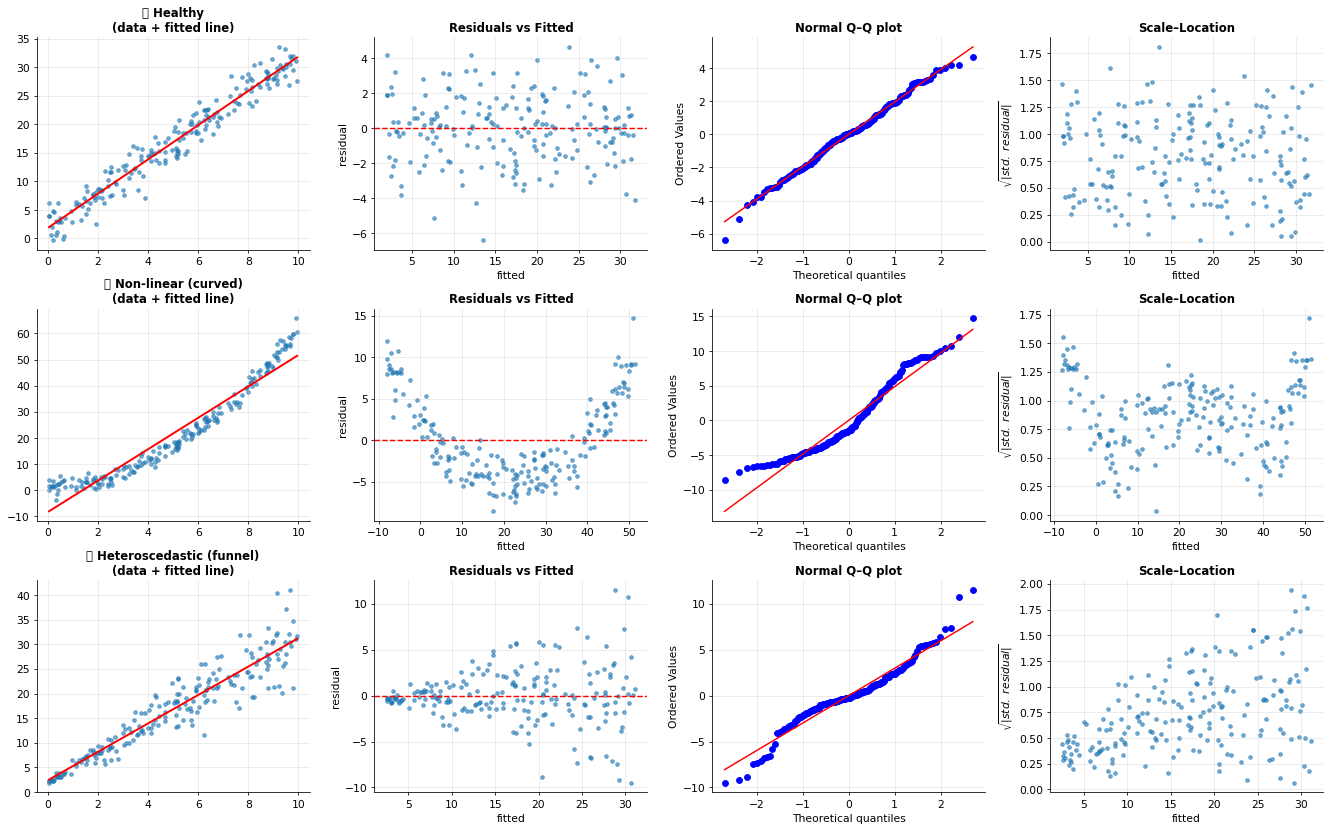

In [20]:
def diag_row(axs, x, y, title):
    Xd = np.c_[np.ones(len(x)), x]
    b = np.linalg.lstsq(Xd, y, rcond=None)[0]; fit = Xd @ b; e = y - fit
    o = np.argsort(x)
    axs[0].scatter(x, y, s=14, alpha=.6); axs[0].plot(x[o], fit[o], "r", lw=2); axs[0].set_title(f"{title}\n(data + fitted line)")
    axs[1].scatter(fit, e, s=14, alpha=.6); axs[1].axhline(0, color="r", ls="--")
    axs[1].set(title="Residuals vs Fitted", xlabel="fitted", ylabel="residual")
    stats.probplot(e, dist="norm", plot=axs[2]); axs[2].set_title("Normal Q–Q plot")
    std = e / e.std(ddof=2)
    axs[3].scatter(fit, np.sqrt(np.abs(std)), s=14, alpha=.6); axs[3].set(title="Scale–Location", xlabel="fitted", ylabel=r"$\sqrt{|std.\ residual|}$")

rng = np.random.default_rng(7); m = 200
xg = rng.uniform(0, 10, m)
datasets = {
    "✅ Healthy": 2 + 3 * xg + rng.normal(0, 2, m),
    "❌ Non-linear (curved)": 2 + 0.6 * xg**2 + rng.normal(0, 2, m),
    "❌ Heteroscedastic (funnel)": 2 + 3 * xg + rng.normal(0, 1, m) * (0.2 + 0.5 * xg),
}
fig, axes = plt.subplots(3, 4, figsize=(19, 12))
for row, (name, yy) in zip(axes, datasets.items()):
    diag_row(row, xg, yy, name)
plt.tight_layout(); plt.show()

**How to read them**
* **Residuals vs Fitted** – want a random horizontal band. A **U-shape ⇒ non-linearity**; a **funnel ⇒ heteroscedasticity**.
* **Q–Q plot** – residual quantiles vs Normal quantiles; points on the diagonal ⇒ normal. S-curves/heavy tails ⇒ non-normal.
* **Scale–Location** – a rising trend ⇒ variance grows with the fitted value.

### 6.1 Formal tests (implemented by hand so you see the mechanics)
* **Shapiro–Wilk** ($H_0$: residuals are Normal).
* **Breusch–Pagan** ($H_0$: constant variance): regress $e_i^2$ on the predictors; $LM=n\cdot R^2_{aux}\sim\chi^2_p$.
* **Durbin–Watson** (autocorrelation): $DW=\dfrac{\sum_t(e_t-e_{t-1})^2}{\sum_t e_t^2}\approx2(1-\hat\rho)$. About 2 ⇒ no autocorrelation; near 0 ⇒ positive; near 4 ⇒ negative.

(In Section 7 we call the ready-made statsmodels versions.)

In [21]:
def tests(x, y):
    Xd = np.c_[np.ones(len(x)), x]
    b = np.linalg.lstsq(Xd, y, rcond=None)[0]; e = y - Xd @ b
    sh_p = stats.shapiro(e).pvalue
    b_aux = np.linalg.lstsq(Xd, e**2, rcond=None)[0]; e2 = e**2
    r2_aux = 1 - ((e2 - Xd @ b_aux)**2).sum() / ((e2 - e2.mean())**2).sum()
    bp_p = stats.chi2.sf(len(x) * r2_aux, df=1)
    o = np.argsort(x); eo = e[o]
    dw = np.sum(np.diff(eo)**2) / np.sum(eo**2)
    return {"Shapiro p (normality)": sh_p, "Breusch-Pagan p (const. var.)": bp_p, "Durbin-Watson": dw}

out = pd.DataFrame({name: tests(xg, yy) for name, yy in datasets.items()}).T
display(out)
print("Reject H0 when p < 0.05.  Notice: the funnel dataset fails Breusch–Pagan; the curved one fails Durbin–Watson (patterned residuals when sorted by x) and typically Shapiro.")

Reject H0 when p < 0.05.  Notice: the funnel dataset fails Breusch–Pagan; the curved one fails Durbin–Watson (patterned residuals when sorted by x) and typically Shapiro.


,Shapiro p (normality),Breusch-Pagan p (const. var.),Durbin-Watson
✅ Healthy,0.5614,0.5749,2.0105
❌ Non-linear (curved),0.0000,0.7337,0.2466
❌ Heteroscedastic (funnel),0.0000,0.0000,2.1726


### 6.2 Outliers, leverage & influence
Not every unusual point matters equally:
* **Outlier** – large residual (unusual $y$ given $x$).
* **High leverage** – unusual $x$; measured by the diagonal of the hat matrix, $h_{ii}=\mathbf x_i^\top(\mathbf X^\top\mathbf X)^{-1}\mathbf x_i$ (average $=(p+1)/n$; flag $>2(p+1)/n$).
* **Influential** – removing the point *changes the fit substantially*: usually high leverage **and** large residual. **Cook's distance**
$$D_i=\frac{e_i^2}{(p+1)s^2}\cdot\frac{h_{ii}}{(1-h_{ii})^2}\qquad(\text{flag }D_i>4/n)$$
* **Studentised residual:** $r_i=\dfrac{e_i}{s\sqrt{1-h_{ii}}}$ (|r| > 3 is suspicious).

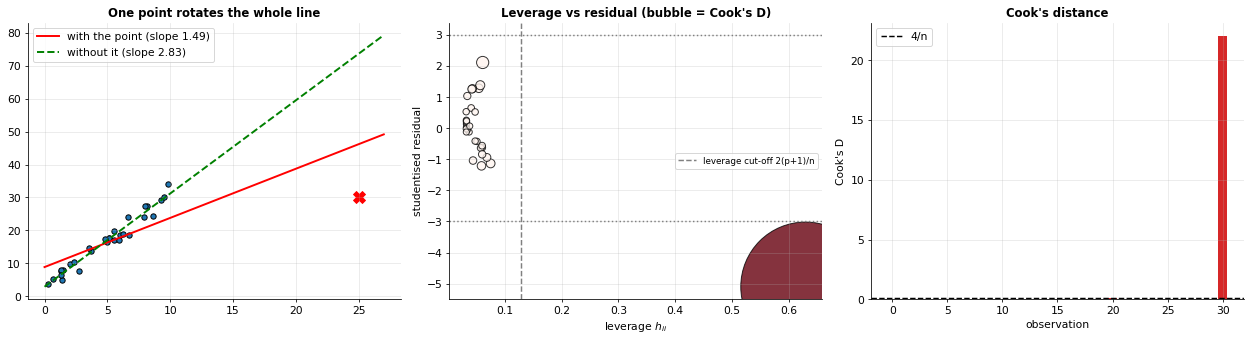

Flagged by Cook's D > 4/n: observations [20, 30]


In [22]:
rng = np.random.default_rng(11)
xi = rng.uniform(0, 10, 30); yi = 2 + 3 * xi + rng.normal(0, 2, 30)
xi = np.append(xi, 25); yi = np.append(yi, 30)                    # a far-away x with an off-trend y  → influential!

Xi = np.c_[np.ones(len(xi)), xi]; pp = 1
bi = np.linalg.lstsq(Xi, yi, rcond=None)[0]; ei = yi - Xi @ bi
h = np.diag(Xi @ np.linalg.inv(Xi.T @ Xi) @ Xi.T)
s2i = ei @ ei / (len(xi) - pp - 1)
stud = ei / np.sqrt(s2i * (1 - h))
cook = ei**2 / ((pp + 1) * s2i) * h / (1 - h)**2

b_clean = np.polyfit(xi[:-1], yi[:-1], 1)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
gg = np.linspace(0, 27, 50)
ax[0].scatter(xi, yi, s=30, edgecolor="k"); ax[0].scatter(xi[-1], yi[-1], s=150, color="red", marker="X")
ax[0].plot(gg, bi[0] + bi[1] * gg, "r", lw=2, label=f"with the point (slope {bi[1]:.2f})")
ax[0].plot(gg, b_clean[1] + b_clean[0] * gg, "g--", lw=2, label=f"without it (slope {b_clean[0]:.2f})"); ax[0].legend(); ax[0].set_title("One point rotates the whole line")
sc = ax[1].scatter(h, stud, s=40 + 800 * cook, c=cook, cmap="Reds", edgecolor="k", alpha=.8)
ax[1].axvline(2 * (pp + 1) / len(xi), color="grey", ls="--", label="leverage cut-off 2(p+1)/n"); ax[1].axhline(3, color="grey", ls=":"); ax[1].axhline(-3, color="grey", ls=":")
ax[1].set(xlabel="leverage $h_{ii}$", ylabel="studentised residual", title="Leverage vs residual (bubble = Cook's D)"); ax[1].legend(fontsize=9)
ax[2].bar(range(len(cook)), cook, color=np.where(cook > 4 / len(xi), "tab:red", "tab:blue")); ax[2].axhline(4 / len(xi), color="k", ls="--", label="4/n")
ax[2].set(xlabel="observation", ylabel="Cook's D", title="Cook's distance"); ax[2].legend()
plt.tight_layout(); plt.show()
print(f"Flagged by Cook's D > 4/n: observations {np.where(cook > 4 / len(xi))[0].tolist()}")

**What to do with influential points?** Investigate first (data-entry error? genuinely different population?). Delete only with a *documented* reason. Otherwise use robust regression (Huber) or report results with and without the point.

## 7. Linear Regression with **statsmodels** (the statistician's tool)

`statsmodels` is built for **inference**: it gives coefficient tables, p-values, confidence intervals and diagnostics out-of-the-box.

Two important API facts:
* `sm.OLS(y, X)` **does not add an intercept automatically** → use `sm.add_constant(X)`.
* The formula API `smf.ols("y ~ x1 + x2", data=df)` (R-style) **adds the intercept for you** and handles categoricals with `C(var)`.

### 7.1 Fit and print the summary

In [ ]:
X_sm = sm.add_constant(df_study[["hours"]])          # adds a column of ones named 'const'
ols = sm.OLS(df_study["score"], X_sm).fit()
print(ols.summary())

### 7.2 Reading `summary()` line by line

**Top-left block — model description**
| Field | Meaning |
|---|---|
| Dep. Variable | the target $y$ |
| Model / Method | OLS / Least Squares |
| No. Observations | $n$ |
| Df Residuals | $n-p-1$ (degrees of freedom left after estimating parameters) |
| Df Model | $p$ (number of predictors, intercept excluded) |
| Covariance Type | `nonrobust` = classical $\sigma^2(\mathbf X^\top\mathbf X)^{-1}$ (assumes homoscedasticity). Alternatives: `HC0–HC3` (robust), `cluster`, `HAC` |

**Top-right block — overall fit**
| Field | Meaning |
|---|---|
| R-squared | $1-\text{SSE}/\text{SST}$ — variance explained |
| Adj. R-squared | penalised for the number of predictors |
| F-statistic, Prob (F-statistic) | joint test that *all* slopes are 0; small p ⇒ the model as a whole is useful |
| Log-Likelihood | Gaussian $\ell$ from Section 4 |
| AIC / BIC | $2k-2\ell$ and $k\ln n-2\ell$ — compare *competing models on the same data* (lower = better) |

**Middle block — coefficient table**
| Column | Meaning |
|---|---|
| coef | $\hat\beta_j$ |
| std err | $\text{SE}(\hat\beta_j)$ — precision of the estimate |
| t | $\hat\beta_j/\text{SE}$ |
| P>\|t\| | two-sided p-value for $H_0:\beta_j=0$ |
| [0.025, 0.975] | 95% confidence interval |

**Bottom block — residual diagnostics**
| Field | Meaning |
|---|---|
| Omnibus / Prob(Omnibus) | D'Agostino test of normality of residuals (skewness + kurtosis) |
| Skew | 0 for symmetric residuals |
| Kurtosis | 3 for Normal; >3 heavy tails |
| Durbin-Watson | ≈2 ⇒ no first-order autocorrelation |
| Jarque-Bera (JB) / Prob(JB) | another normality test |
| Cond. No. | condition number of $\mathbf X$; large (>30 by rule of thumb, e.g. unscaled features) hints at multicollinearity/numerical issues |

The footnote **[1] Standard Errors assume that the covariance matrix of the errors is correctly specified** is a reminder that all p-values rely on the assumptions in Section 6.

### 7.3 Programmatic access & agreement with our hand computation

In [ ]:
x = df_study["hours"].values; y = df_study["score"].values     # (re-bind: earlier sections re-used these names)
print("Parameters\n", ols.params, "\n\nStd errors\n", ols.bse, "\n\nt-values\n", ols.tvalues, "\n\np-values\n", ols.pvalues)
print("\n95% CI\n", ols.conf_int(alpha=0.05))
print(f"\nR² = {ols.rsquared:.4f} | adj R² = {ols.rsquared_adj:.4f} | F = {ols.fvalue:.2f} (p={ols.f_pvalue:.2e}) | AIC = {ols.aic:.2f} | BIC = {ols.bic:.2f} | s = {np.sqrt(ols.mse_resid):.4f}")

print("\nMatches Section 4 (by hand)?")
print("  coefficients :", np.allclose(ols.params.values, beta))
print("  std errors   :", np.allclose(ols.bse.values, se))
print("  p-values     :", np.allclose(ols.pvalues.values, p_vals))
print("  AIC / BIC    :", np.isclose(ols.aic, summary_by_hand['AIC']), np.isclose(ols.bic, summary_by_hand['BIC']))

### 7.4 Formula API, robust standard errors, and prediction intervals

In [ ]:
# (a) R-style formula – intercept is automatic
ols_f = smf.ols("score ~ hours", data=df_study).fit()
print("Formula API params:", ols_f.params.round(4).to_dict())

# (b) Heteroscedasticity-robust (White / HC3) standard errors – same coefficients, safer SEs & p-values
ols_rob = smf.ols("score ~ hours", data=df_study).fit(cov_type="HC3")
print("\nClassical SE :", ols_f.bse.round(4).to_dict())
print("Robust HC3 SE:", ols_rob.bse.round(4).to_dict())

# (c) Confidence and prediction intervals for new inputs
new = pd.DataFrame({"hours": [2, 5, 8, 10]})
pred = ols_f.get_prediction(new).summary_frame(alpha=0.05)
pred.insert(0, "hours", new["hours"])
display(pred.rename(columns={"mean": "prediction", "mean_ci_lower": "CI_low", "mean_ci_upper": "CI_high", "obs_ci_lower": "PI_low", "obs_ci_upper": "PI_high"}))

# (d) Plot the bands straight from statsmodels
grid = pd.DataFrame({"hours": np.linspace(0, 11, 100)})
sf = ols_f.get_prediction(grid).summary_frame(alpha=0.05)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x, y, s=30, edgecolor="k", alpha=.7)
ax.plot(grid["hours"], sf["mean"], "r", lw=2)
ax.fill_between(grid["hours"], sf["mean_ci_lower"], sf["mean_ci_upper"], color="tab:red", alpha=.35, label="95% CI (mean)")
ax.fill_between(grid["hours"], sf["obs_ci_lower"], sf["obs_ci_upper"], color="tab:blue", alpha=.15, label="95% PI (individual)")
ax.set(xlabel="Hours", ylabel="Score", title="statsmodels intervals (identical to Section 4.3)"); ax.legend(); plt.show()

### 7.5 Ready-made diagnostics

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor

bp = het_breuschpagan(ols.resid, ols.model.exog)
jb = jarque_bera(ols.resid)
print(f"Breusch–Pagan  LM = {bp[0]:.3f}, p = {bp[1]:.3f}   (H0: constant variance)")
print(f"Jarque–Bera    JB = {jb[0]:.3f}, p = {jb[1]:.3f}   (H0: normal residuals)")
print(f"Durbin–Watson  DW = {durbin_watson(ols.resid):.3f}   (≈2 ⇒ independent)")

infl = ols.get_influence()
d = pd.DataFrame({"leverage": infl.hat_matrix_diag, "student_resid": infl.resid_studentized_external, "cooks_d": infl.cooks_distance[0]})
print("\nTop 3 most influential observations:"); display(d.sort_values("cooks_d", ascending=False).head(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
sm.qqplot(ols.resid, line="s", ax=ax[0]); ax[0].set_title("statsmodels Q–Q plot")
ax[1].scatter(ols.fittedvalues, ols.resid, s=25, alpha=.7); ax[1].axhline(0, color="r", ls="--")
ax[1].set(xlabel="fitted", ylabel="residual", title="Residuals vs fitted"); plt.tight_layout(); plt.show()

### 7.6 Multiple regression + categorical variable in statsmodels
`C(group)` creates dummy columns automatically. `I(x**2)` and `np.log(x)` are allowed inside formulas. `x1:x2` is an interaction (`x1*x2` = both main effects + interaction).

In [ ]:
df_m2 = df_m.copy()
rng = np.random.default_rng(5)
df_m2["group"] = rng.choice(["A", "B", "C"], size=len(df_m2))
df_m2["y"] = df_m2["y"] + df_m2["group"].map({"A": 0, "B": 2.0, "C": -1.0})      # inject known group effects

ols_multi = smf.ols("y ~ x1 + x2 + x3 + C(group)", data=df_m2).fit()
print(ols_multi.summary().tables[1])                                              # only the coefficient table
print("\nTrue effects: x1=2, x2=-1.5, x3=0.5, B vs A=+2, C vs A=-1  (A is the baseline)")

# VIFs for the numeric predictors
Xv = sm.add_constant(df_m2[["x1", "x2", "x3"]])
print("\nVIF:", {c: round(variance_inflation_factor(Xv.values, i), 2) for i, c in enumerate(Xv.columns) if c != "const"})

## 8. Linear Regression with **scikit-learn** (the machine-learner's tool)

scikit-learn focuses on **prediction & generalisation**: a uniform `fit / predict / score` API, pipelines, train/test splitting, cross-validation and hyper-parameter tuning. It deliberately provides *no* p-values or confidence intervals.

Key points about `LinearRegression`:
* Adds the intercept for you (`fit_intercept=True`); coefficients are in `coef_`, intercept in `intercept_`.
* Solves least squares via SVD (`scipy.linalg.lstsq`) — no gradient descent.
* `X` must be 2-D: shape `(n_samples, n_features)`.
* `.score(X, y)` returns $R^2$.

### 8.1 Fit, predict, evaluate

In [23]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

Xs = df_study[["hours"]]; ys = df_study["score"]
lin = LinearRegression().fit(Xs, ys)
print(f"intercept_ = {lin.intercept_:.4f},  coef_ = {lin.coef_[0]:.4f},  R² = {lin.score(Xs, ys):.4f}")
print("Prediction for 6.5 hours:", round(float(lin.predict(pd.DataFrame({'hours': [6.5]}))[0]), 2))

# --- proper evaluation: hold out a test set the model never sees
X_tr, X_te, y_tr, y_te = train_test_split(Xs, ys, test_size=0.25, random_state=0)
m = LinearRegression().fit(X_tr, y_tr)
for name, (Xa, ya) in {"train": (X_tr, y_tr), "test": (X_te, y_te)}.items():
    pr = m.predict(Xa)
    print(f"{name:5s}: R² = {metrics.r2_score(ya, pr):.3f} | RMSE = {np.sqrt(metrics.mean_squared_error(ya, pr)):.3f} | MAE = {metrics.mean_absolute_error(ya, pr):.3f}")

intercept_ = 37.3518,  coef_ = 5.1083,  R² = 0.9070
Prediction for 6.5 hours: 70.56
train: R² = 0.902 | RMSE = 4.140 | MAE = 3.540
test : R² = 0.917 | RMSE = 4.411 | MAE = 3.606


### 8.2 Cross-validation
A single split is noisy (lucky/unlucky test set). **$K$-fold CV** splits the data in $K$ parts, trains on $K-1$, tests on the remaining one, and rotates:
$$\text{CV-RMSE}=\frac1K\sum_{k=1}^K \text{RMSE}_k$$
This gives an honest estimate of **out-of-sample** error *and* its variability.

RMSE per fold: [4.65 4.13 3.56 4.96 5.03] → mean 4.46 ± 0.55
R²   per fold: [0.919 0.886 0.938 0.797 0.827] → mean 0.873


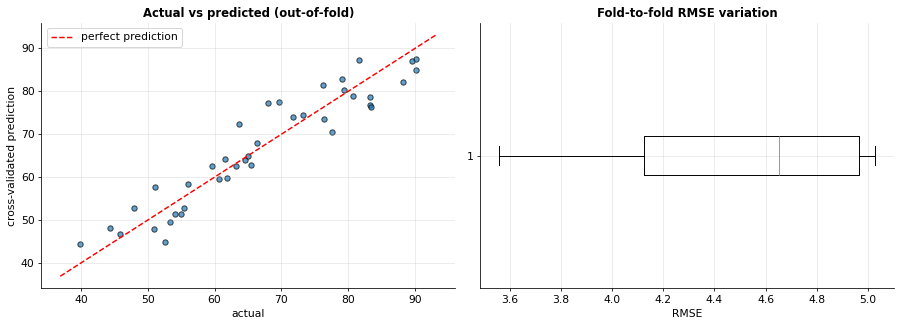

In [24]:
kf = KFold(n_splits=5, shuffle=True, random_state=0)
rmse_cv = -cross_val_score(LinearRegression(), Xs, ys, cv=kf, scoring="neg_root_mean_squared_error")
r2_cv = cross_val_score(LinearRegression(), Xs, ys, cv=kf, scoring="r2")
print("RMSE per fold:", rmse_cv.round(2), f"→ mean {rmse_cv.mean():.2f} ± {rmse_cv.std():.2f}")
print("R²   per fold:", r2_cv.round(3), f"→ mean {r2_cv.mean():.3f}")

pred_cv = cross_val_predict(LinearRegression(), Xs, ys, cv=kf)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].scatter(ys, pred_cv, s=30, edgecolor="k", alpha=.7); lim = [ys.min() - 3, ys.max() + 3]
ax[0].plot(lim, lim, "r--", label="perfect prediction"); ax[0].set(xlabel="actual", ylabel="cross-validated prediction", title="Actual vs predicted (out-of-fold)"); ax[0].legend()
ax[1].boxplot(rmse_cv, vert=False); ax[1].set(title="Fold-to-fold RMSE variation", xlabel="RMSE")
plt.tight_layout(); plt.show()

### 8.3 Pipelines & scaling
A `Pipeline` chains preprocessing + model so that **scaling parameters are learned from training data only** (avoiding *data leakage*). For plain OLS, scaling doesn't change predictions, only the meaning of coefficients (per 1 standard deviation instead of per unit) — but it is *essential* for gradient-based solvers and for regularisation (Section 9).

$$\hat y=\beta_0+\beta_1x=\underbrace{(\beta_0+\beta_1\mu)}_{\gamma_0}+\underbrace{(\beta_1\sigma)}_{\gamma_1}\,\frac{x-\mu}{\sigma}$$

In [25]:
pipe = make_pipeline(StandardScaler(), LinearRegression()).fit(Xs, ys)
lr_step, sc_step = pipe[-1], pipe[0]
gamma0, gamma1 = lr_step.intercept_, lr_step.coef_[0]
mu_, sd_ = sc_step.mean_[0], sc_step.scale_[0]
print(f"Scaled model: intercept={gamma0:.3f} (=mean of y {ys.mean():.3f}), slope per 1 SD of hours = {gamma1:.3f}")
print(f"Back to original units: slope = {gamma1 / sd_:.4f}, intercept = {gamma0 - gamma1 * mu_ / sd_:.4f}   (matches LinearRegression)")

# SGDRegressor = gradient-descent version of the same model (Section 3.4/3.5)
sgd_m = make_pipeline(StandardScaler(), SGDRegressor(loss="squared_error", penalty=None, learning_rate="constant", eta0=0.01, max_iter=5000, tol=1e-8, random_state=0)).fit(Xs, ys)
g0, g1 = sgd_m[-1].intercept_[0], sgd_m[-1].coef_[0]
print(f"SGDRegressor in original units: slope = {g1 / sd_:.4f}, intercept = {g0 - g1 * mu_ / sd_:.4f}")

Scaled model: intercept=66.992 (=mean of y 66.992), slope per 1 SD of hours = 13.131
Back to original units: slope = 5.1083, intercept = 37.3518   (matches LinearRegression)
SGDRegressor in original units: slope = 5.1014, intercept = 37.3253


### 8.4 All roads lead to the same line

In [26]:
comp = pd.DataFrame({
    "closed form (Sec 3.1)":  [b0, b1],
    "normal equation":        beta_solve,
    "np.linalg.lstsq":        beta_lstsq,
    "gradient descent (3.4)": [b0_gd, b1_gd],
    "statsmodels OLS":        ols.params.values,
    "sklearn LinearRegression": [lin.intercept_, lin.coef_[0]],
    "sklearn SGDRegressor":   [g0 - g1 * mu_ / sd_, g1 / sd_],
}, index=["intercept β0", "slope β1"]).T
display(comp)
print("True values used to generate the data: β0 = 35, β1 = 5.5")

True values used to generate the data: β0 = 35, β1 = 5.5


,intercept β0,slope β1
closed form (Sec 3.1),37.3518,5.1083
normal equation,37.3518,5.1083
np.linalg.lstsq,37.3518,5.1083
gradient descent (3.4),37.3518,5.1083
statsmodels OLS,37.3518,5.1083
sklearn LinearRegression,37.3518,5.1083
sklearn SGDRegressor,37.3253,5.1014


### 8.5 statsmodels vs scikit-learn — when to use which
| | statsmodels | scikit-learn |
|---|---|---|
| Goal | **Explain** (inference, hypothesis tests) | **Predict** (generalisation) |
| p-values, CIs, AIC/BIC, diagnostics | ✅ built in | ❌ |
| Intercept | manual `add_constant` (or formula) | automatic |
| Train/test, CV, pipelines, tuning | ❌ (manual) | ✅ |
| Regularisation | limited (`fit_regularized`) | ✅ Ridge, Lasso, ElasticNet, … |
| Typical workflow | econometrics, science, A/B analysis | ML products, benchmarking |

In practice, **use both**: scikit-learn to validate predictive performance, statsmodels to understand and defend the coefficients.

---
## 9. Regularization: Ridge, Lasso & Elastic Net

**Problem.** With many, noisy or correlated features OLS **over-fits**: coefficients become huge and unstable (variance ↑). **Regularisation** adds a penalty on coefficient size, trading a little **bias** for a big drop in **variance**.

| Method | Objective (minimise) | Effect |
|---|---|---|
| **OLS** | $\lVert\mathbf y-\mathbf X\boldsymbol\beta\rVert_2^2$ | unbiased, may have high variance |
| **Ridge (L2)** | $\lVert\mathbf y-\mathbf X\boldsymbol\beta\rVert_2^2+\alpha\lVert\boldsymbol\beta\rVert_2^2$ | *shrinks* all coefficients toward 0; handles collinearity; never exactly 0 |
| **Lasso (L1)** | $\dfrac1{2n}\lVert\mathbf y-\mathbf X\boldsymbol\beta\rVert_2^2+\alpha\lVert\boldsymbol\beta\rVert_1$ | shrinks *and* sets some coefficients **exactly to 0** ⇒ automatic feature selection |
| **Elastic Net** | $\dfrac1{2n}\lVert\mathbf y-\mathbf X\boldsymbol\beta\rVert_2^2+\alpha\big[\rho\lVert\boldsymbol\beta\rVert_1+\tfrac{1-\rho}2\lVert\boldsymbol\beta\rVert_2^2\big]$ | mix of both; good with groups of correlated features |

(scikit-learn's exact scaling conventions: `Ridge` uses no $1/2n$, `Lasso`/`ElasticNet` do.) The intercept is **not** penalised. **Always standardise features first**, otherwise the penalty depends on the units.

**Ridge has a closed form:** $\hat{\boldsymbol\beta}_{ridge}=(\mathbf X^\top\mathbf X+\alpha\mathbf I)^{-1}\mathbf X^\top\mathbf y$ — adding $\alpha\mathbf I$ makes the matrix invertible even under perfect collinearity and shrinks small-eigenvalue directions most.

**Bayesian view:** Ridge = MAP estimate with a **Gaussian prior** on $\beta$; Lasso = MAP with a **Laplace prior**.

### 9.1 Geometry: why L1 gives zeros and L2 doesn't
Equivalent constrained form: minimise SSE **subject to** $\lVert\boldsymbol\beta\rVert\le t$. The SSE contours are ellipses centred at the OLS solution; the solution is where an ellipse first touches the constraint region. The **L1 region is a diamond with sharp corners on the axes** — the ellipse usually hits a corner ⇒ one coefficient is exactly 0. The **L2 region is a smooth disc**, so the touching point rarely lies on an axis.

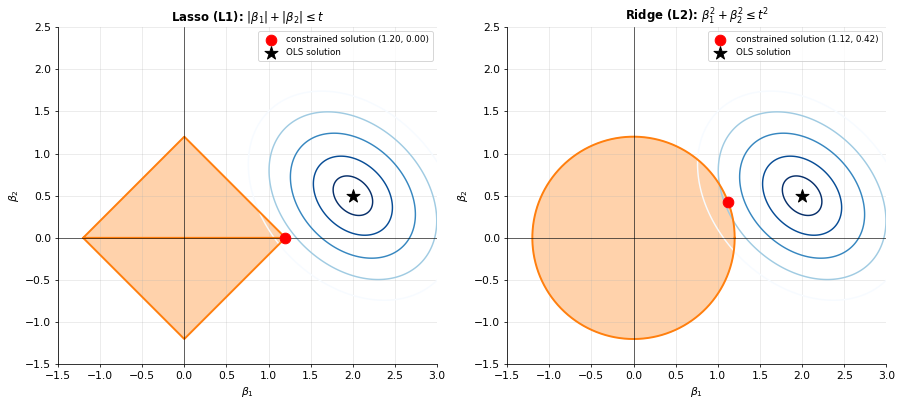

In [27]:
c = np.array([2.0, 0.5])                                   # OLS solution
A = np.array([[1.0, 0.3], [0.3, 1.0]])
g = np.linspace(-1, 3, 400); G1, G2 = np.meshgrid(g, g)
D = np.stack([G1 - c[0], G2 - c[1]], -1)
Q = np.einsum("...i,ij,...j->...", D, A, D)               # SSE-like quadratic form

th = np.linspace(0, 2 * np.pi, 2000); t_budget = 1.2
circle = np.c_[t_budget * np.cos(th), t_budget * np.sin(th)]
u = np.linspace(-1, 1, 1000)
diamond = np.r_[np.c_[t_budget * u, t_budget * (1 - np.abs(u))], np.c_[t_budget * u, -t_budget * (1 - np.abs(u))]]
best = lambda pts: pts[np.argmin(np.einsum("ni,ij,nj->n", pts - c, A, pts - c))]

fig, ax = plt.subplots(1, 2, figsize=(13, 6))
for a_, pts, title in [(ax[0], diamond, "Lasso (L1): $|\\beta_1|+|\\beta_2|\\leq t$"), (ax[1], circle, "Ridge (L2): $\\beta_1^2+\\beta_2^2\\leq t^2$")]:
    a_.contour(G1, G2, Q, levels=[.05, .2, .5, .9, 1.4], cmap="Blues_r")
    a_.fill(*pts.T, color="tab:orange", alpha=.35); a_.plot(*pts.T, color="tab:orange", lw=2)
    sol = best(pts); a_.scatter(*sol, color="red", s=120, zorder=5, label=f"constrained solution ({sol[0]:.2f}, {sol[1]:.2f})")
    a_.scatter(*c, color="k", marker="*", s=200, label="OLS solution", zorder=5)
    a_.axhline(0, color="k", lw=.6); a_.axvline(0, color="k", lw=.6)
    a_.set(xlim=(-1.5, 3), ylim=(-1.5, 2.5), aspect="equal", title=title, xlabel=r"$\beta_1$", ylabel=r"$\beta_2$"); a_.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

### 9.2 Coefficient paths
Data: 10 correlated features but only **4 truly matter** ($\beta=[4,-3,2,0,0,0,0,1,0,0]$). Watch how coefficients shrink as the penalty $\alpha$ grows: Ridge shrinks smoothly, Lasso kills the useless ones first.

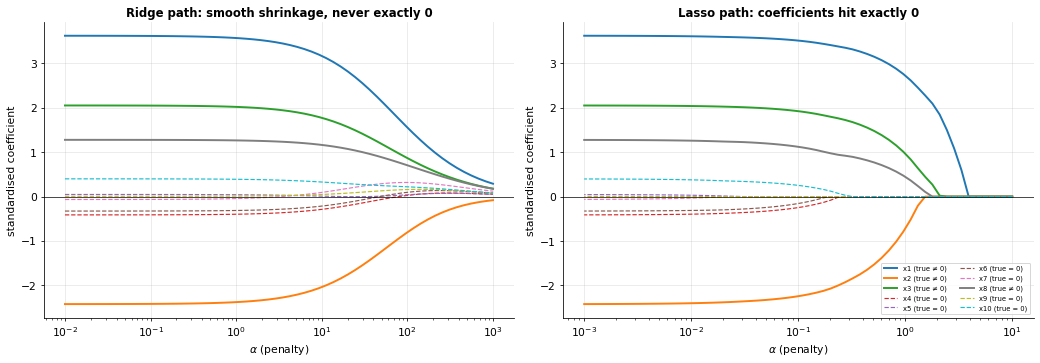

In [28]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV, lasso_path

rng = np.random.default_rng(0)
n_r, p_r = 120, 10
Zc = rng.normal(size=(n_r, 1))
X_r = 0.6 * Zc + 0.8 * rng.normal(size=(n_r, p_r))                 # pairwise corr ≈ 0.36
beta_true = np.array([4, -3, 2, 0, 0, 0, 0, 1, 0, 0.0])
y_r = X_r @ beta_true + rng.normal(0, 2.5, n_r)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_r, y_r, test_size=0.3, random_state=1)
sc = StandardScaler().fit(Xr_tr); Xr_trs, Xr_tes = sc.transform(Xr_tr), sc.transform(Xr_te)
true_std = beta_true * sc.scale_                                    # true coefficients in standardised units

alphas = np.logspace(-2, 3, 60)
ridge_path = np.array([Ridge(alpha=a).fit(Xr_trs, yr_tr).coef_ for a in alphas])
la_alphas, la_coefs, _ = lasso_path(Xr_trs, yr_tr - yr_tr.mean(), alphas=np.logspace(-3, 1, 60))

fig, ax = plt.subplots(1, 2, figsize=(15, 5.3))
cols = plt.cm.tab10(np.arange(p_r))
for j in range(p_r):
    st = "-" if beta_true[j] != 0 else "--"
    ax[0].plot(alphas, ridge_path[:, j], st, color=cols[j], lw=2 if beta_true[j] != 0 else 1.2)
    ax[1].plot(la_alphas, la_coefs[j], st, color=cols[j], lw=2 if beta_true[j] != 0 else 1.2, label=f"x{j + 1}" + (" (true ≠ 0)" if beta_true[j] != 0 else " (true = 0)"))
ax[0].set(xscale="log", xlabel=r"$\alpha$ (penalty)", ylabel="standardised coefficient", title="Ridge path: smooth shrinkage, never exactly 0")
ax[1].set(xscale="log", xlabel=r"$\alpha$ (penalty)", ylabel="standardised coefficient", title="Lasso path: coefficients hit exactly 0"); ax[1].legend(fontsize=7, ncol=2)
for a_ in ax: a_.axhline(0, color="k", lw=.7)
plt.tight_layout(); plt.show()

### 9.3 Choosing $\alpha$ by cross-validation & comparing models

Chosen α → Ridge: 3.486 | Lasso: 0.1050 | ElasticNet: 0.1050 (l1_ratio=1.0)


,true (std. units),OLS,Ridge (CV),Lasso (CV),ElasticNet (CV)
x1,3.6198,3.6233,3.4488,3.5078,3.5078
x2,-2.6487,-2.4223,-2.2733,-2.2346,-2.2346
x3,1.7533,2.0525,1.9445,1.9170,1.9170
x4,0.0000,-0.4127,-0.3630,-0.2390,-0.2390
x5,0.0000,0.0473,0.0296,0.0000,0.0000
x6,0.0000,-0.3264,-0.2831,-0.1465,-0.1465
x7,0.0000,-0.0663,0.0015,0.0000,0.0000
x8,0.9262,1.2782,1.2346,1.1141,1.1141
x9,0.0000,0.0062,0.0220,0.0000,0.0000
x10,0.0000,0.3995,0.3682,0.2467,0.2467


,train RMSE,test RMSE,non-zero coefs
model,,,
OLS,2.5038,2.8849,10
Ridge (CV),2.5141,2.8585,10
Lasso (CV),2.5269,2.7351,7
ElasticNet (CV),2.5269,2.7351,7


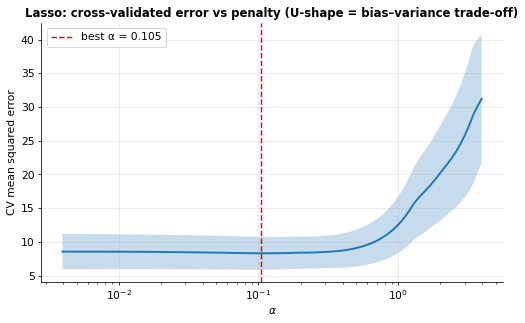

In [29]:
ols_r = LinearRegression().fit(Xr_trs, yr_tr)
ridge_cv = RidgeCV(alphas=np.logspace(-2, 3, 60), cv=5).fit(Xr_trs, yr_tr)
lasso_cv = LassoCV(cv=5, n_alphas=100, random_state=0).fit(Xr_trs, yr_tr)
enet_cv = ElasticNetCV(l1_ratio=[.2, .5, .8, 1.0], cv=5, random_state=0).fit(Xr_trs, yr_tr)

models = {"OLS": ols_r, "Ridge (CV)": ridge_cv, "Lasso (CV)": lasso_cv, "ElasticNet (CV)": enet_cv}
coef_df = pd.DataFrame({k: v.coef_ for k, v in models.items()}, index=[f"x{j + 1}" for j in range(p_r)])
coef_df.insert(0, "true (std. units)", true_std)
display(coef_df)

rows = []
for k, v in models.items():
    rows.append({"model": k, "train RMSE": np.sqrt(metrics.mean_squared_error(yr_tr, v.predict(Xr_trs))),
                 "test RMSE": np.sqrt(metrics.mean_squared_error(yr_te, v.predict(Xr_tes))), "non-zero coefs": int(np.sum(np.abs(v.coef_) > 1e-8))})
display(pd.DataFrame(rows).set_index("model"))
print(f"Chosen α → Ridge: {ridge_cv.alpha_:.3f} | Lasso: {lasso_cv.alpha_:.4f} | ElasticNet: {enet_cv.alpha_:.4f} (l1_ratio={enet_cv.l1_ratio_})")

fig, ax = plt.subplots(figsize=(8.5, 4.8))
mse_mean = lasso_cv.mse_path_.mean(axis=1); mse_sd = lasso_cv.mse_path_.std(axis=1)
ax.plot(lasso_cv.alphas_, mse_mean, lw=2); ax.fill_between(lasso_cv.alphas_, mse_mean - mse_sd, mse_mean + mse_sd, alpha=.25)
ax.axvline(lasso_cv.alpha_, color="r", ls="--", label=f"best α = {lasso_cv.alpha_:.3f}")
ax.set(xscale="log", xlabel=r"$\alpha$", ylabel="CV mean squared error", title="Lasso: cross-validated error vs penalty (U-shape = bias–variance trade-off)"); ax.legend(); plt.show()

## 10. Bias–Variance Trade-off, Polynomial Regression & Over-fitting

For a new point, the expected squared prediction error decomposes as

$$
\mathbb E\big[(y-\hat f(x))^2\big]=\underbrace{\big(\mathbb E[\hat f(x)]-f(x)\big)^2}_{\text{Bias}^2}+\underbrace{\mathbb E\big[(\hat f(x)-\mathbb E\hat f(x))^2\big]}_{\text{Variance}}+\underbrace{\sigma^2}_{\text{irreducible noise}}
$$

* **High bias (under-fitting):** model too simple (a straight line through a sine wave).
* **High variance (over-fitting):** model too flexible; it memorises noise and changes wildly with a different sample.
* Training error *always* falls as complexity grows; **test error is U-shaped** — pick the bottom of the U.

Linear regression can fit curves by using **polynomial features** $[x,x^2,\dots,x^d]$ — still linear in $\beta$.

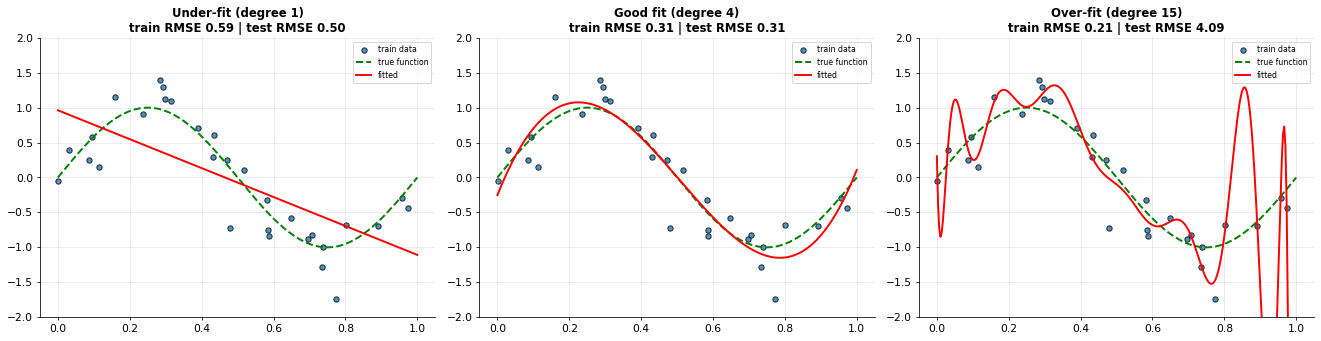

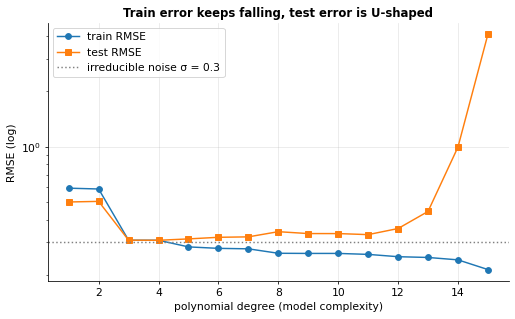

In [30]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import learning_curve

f_true = lambda t: np.sin(2 * np.pi * t)
rng = np.random.default_rng(3)
x_tr_ = rng.uniform(0, 1, 30); y_tr_ = f_true(x_tr_) + rng.normal(0, .3, 30)
x_te_ = rng.uniform(0, 1, 300); y_te_ = f_true(x_te_) + rng.normal(0, .3, 300)
poly_model = lambda d: make_pipeline(PolynomialFeatures(d, include_bias=False), StandardScaler(), LinearRegression())
gx = np.linspace(0, 1, 300)

fig, ax = plt.subplots(1, 3, figsize=(19, 5))
for a_, d, lab in zip(ax, [1, 4, 15], ["Under-fit (degree 1)", "Good fit (degree 4)", "Over-fit (degree 15)"]):
    mdl = poly_model(d).fit(x_tr_.reshape(-1, 1), y_tr_)
    a_.scatter(x_tr_, y_tr_, s=30, edgecolor="k", alpha=.8, label="train data")
    a_.plot(gx, f_true(gx), "g--", lw=2, label="true function"); a_.plot(gx, mdl.predict(gx.reshape(-1, 1)), "r", lw=2, label="fitted")
    te = np.sqrt(metrics.mean_squared_error(y_te_, mdl.predict(x_te_.reshape(-1, 1)))); tr = np.sqrt(metrics.mean_squared_error(y_tr_, mdl.predict(x_tr_.reshape(-1, 1))))
    a_.set(ylim=(-2, 2), title=f"{lab}\ntrain RMSE {tr:.2f} | test RMSE {te:.2f}"); a_.legend(fontsize=8)
plt.tight_layout(); plt.show()

degs = range(1, 16)
tr_err, te_err = [], []
for d in degs:
    mdl = poly_model(d).fit(x_tr_.reshape(-1, 1), y_tr_)
    tr_err.append(np.sqrt(metrics.mean_squared_error(y_tr_, mdl.predict(x_tr_.reshape(-1, 1)))))
    te_err.append(np.sqrt(metrics.mean_squared_error(y_te_, mdl.predict(x_te_.reshape(-1, 1)))))
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(degs, tr_err, "o-", label="train RMSE"); ax.plot(degs, te_err, "s-", label="test RMSE")
ax.axhline(0.3, color="grey", ls=":", label="irreducible noise σ = 0.3"); ax.set(yscale="log", xlabel="polynomial degree (model complexity)", ylabel="RMSE (log)", title="Train error keeps falling, test error is U-shaped"); ax.legend(); plt.show()

### 10.1 Measuring bias and variance by simulation
Draw **150 different training sets** from the same process, fit each, and look at the *cloud* of fitted curves.

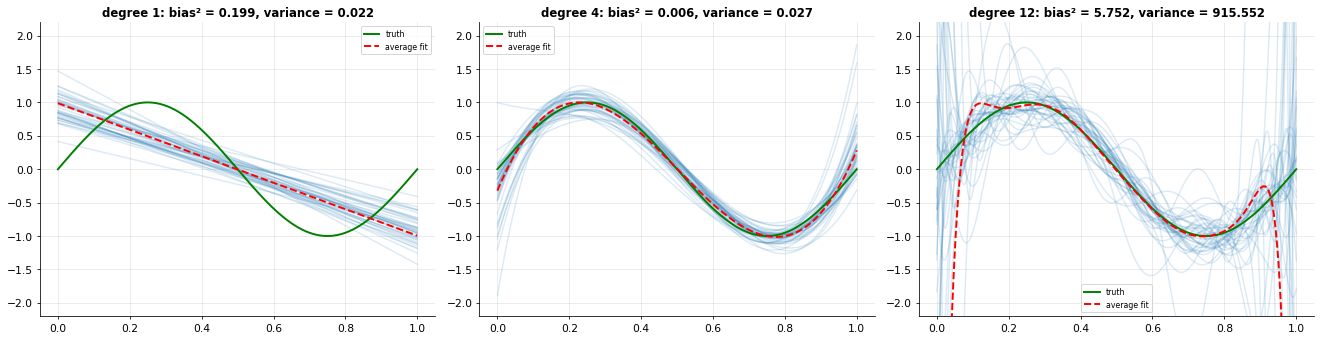

,Bias²,Variance,Noise σ²,Bias²+Var+σ²
degree,,,,
1,0.1992,0.0223,0.0900,0.3114
4,0.0058,0.0275,0.0900,0.1232
12,5.7522,915.5516,0.0900,921.3938


In [31]:
rng = np.random.default_rng(10)
reps, degs_show = 150, [1, 4, 12]
preds = {d: [] for d in degs_show}
for _ in range(reps):
    xx = rng.uniform(0, 1, 30); yy = f_true(xx) + rng.normal(0, .3, 30)
    for d in degs_show:
        preds[d].append(poly_model(d).fit(xx.reshape(-1, 1), yy).predict(gx.reshape(-1, 1)))

fig, ax = plt.subplots(1, 3, figsize=(19, 5)); rows = []
for a_, d in zip(ax, degs_show):
    P = np.array(preds[d]); mean_pred = P.mean(0)
    for row in P[:40]: a_.plot(gx, row, color="tab:blue", alpha=.15)
    a_.plot(gx, f_true(gx), "g", lw=2, label="truth"); a_.plot(gx, mean_pred, "r--", lw=2, label="average fit")
    bias2 = np.mean((mean_pred - f_true(gx))**2); var = np.mean(P.var(0)); rows.append({"degree": d, "Bias²": bias2, "Variance": var, "Noise σ²": .09, "Bias²+Var+σ²": bias2 + var + .09})
    a_.set(ylim=(-2.2, 2.2), title=f"degree {d}: bias² = {bias2:.3f}, variance = {var:.3f}"); a_.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(pd.DataFrame(rows).set_index("degree"))

### 10.2 Learning curves — do I need more data or a better model?
Plot train/validation error against training-set size. **Both curves high & converged** ⇒ high bias (add features/complexity). **Large gap** between curves ⇒ high variance (more data or regularisation helps).

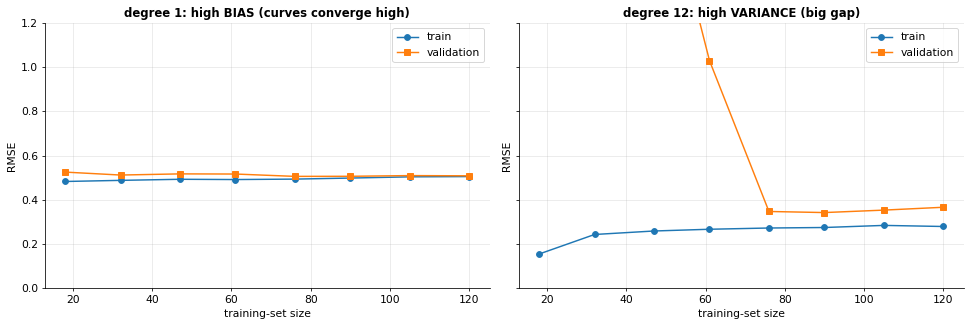

In [32]:
Xp = np.r_[x_tr_, x_te_[:120]].reshape(-1, 1); yp = np.r_[y_tr_, y_te_[:120]]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for a_, d in zip(ax, [1, 12]):
    sizes, trs, vas = learning_curve(poly_model(d), Xp, yp, cv=5, scoring="neg_root_mean_squared_error", train_sizes=np.linspace(.15, 1, 8), random_state=0, shuffle=True)
    a_.plot(sizes, -trs.mean(1), "o-", label="train"); a_.plot(sizes, -vas.mean(1), "s-", label="validation")
    a_.set(title=f"degree {d}: " + ("high BIAS (curves converge high)" if d == 1 else "high VARIANCE (big gap)"), xlabel="training-set size", ylabel="RMSE", ylim=(0, 1.2)); a_.legend()
plt.tight_layout(); plt.show()

---
## 11. 🏠 Real-Life Case Study — Predicting House Prices

### 11.1 The business problem
A property-listing platform wants a **price-estimation tool** that helps sellers set a realistic asking price and helps buyers judge whether a listing is fair. The product team needs two things:

1. **Prediction:** *"What is a sensible price for this house?"* (with an honest range, not just one number)
2. **Explanation:** *"What is each feature worth?"* (e.g., what does an extra bathroom or 10 more years of age do to the price?)

This is a classic **regression** problem — and exactly where **both** tools shine: *statsmodels* to explain and defend the coefficients, *scikit-learn* to validate predictive performance.

### 11.2 The workflow we will follow
`Data → Understand → EDA → Split → Clean/Impute → Feature-engineer → Check collinearity → Baseline → Fix (log transform) → Detect bad records → Fit final model (statsmodels) → Diagnostics → Validate (sklearn, CV, test set) → Compare regularised models → Interpret → Predict with intervals → Business insights`

### 11.3 The data
To keep the notebook self-contained (no downloads) we **simulate** a realistic housing dataset (prices in **₹ lakh**, areas in sq ft) with the messiness of real data: skewed prices, missing values, and a few wrongly-entered prices. The generating recipe is *known*, which lets us check whether the regression recovers the truth — something you can never do with real data. (To use your own data, replace the next cell with `df = pd.read_csv("your_file.csv")` and keep the column names.)

In [33]:
rng = np.random.default_rng(2024)
N = 1500
area      = np.clip(rng.normal(1100, 350, N), 350, 3000).round()
bedrooms  = np.clip(np.round(area / 420 + rng.normal(0, .6, N)), 1, 5).astype(int)
bathrooms = np.clip(bedrooms - rng.integers(0, 2, N), 1, 4)
age       = rng.uniform(0, 30, N).round(1)
dist      = (rng.exponential(7, N) + 1).round(1)
locality  = rng.choice(["Prime", "Suburban", "Outskirts"], N, p=[.25, .45, .30])
parking   = rng.binomial(1, .6, N)
loc_eff   = pd.Series(locality).map({"Prime": .35, "Suburban": .15, "Outskirts": 0.0}).values

# The hidden "true" market mechanism is MULTIPLICATIVE (log-linear) with noise sd = 0.12
TRUE = {"area_sqft": .0009, "bedrooms": .04, "bathrooms": .03, "age_years": -.012, "dist_center_km": -.015, "parking": .06, "loc_Suburban": .15, "loc_Prime": .35}
log_price = 3.2 + .0009 * area + .04 * bedrooms + .03 * bathrooms - .012 * age - .015 * dist + loc_eff + .06 * parking + rng.normal(0, .12, N)
price = np.exp(log_price)

bad_idx = rng.choice(N, 8, replace=False)      # data-entry errors: price typed 3x too high
price[bad_idx] *= 3
age = age.astype(float); dist = dist.astype(float)
age[rng.choice(N, int(.04 * N), replace=False)] = np.nan            # 4% missing age
dist[rng.choice(N, int(.03 * N), replace=False)] = np.nan           # 3% missing distance

df = pd.DataFrame({"area_sqft": area, "bedrooms": bedrooms, "bathrooms": bathrooms, "age_years": age,
                   "dist_center_km": dist, "locality": locality, "parking": parking, "price_lakh": price})
display(df.head(8))

,area_sqft,bedrooms,bathrooms,age_years,dist_center_km,locality,parking,price_lakh
0,"1,460.0000",3,2,14.9000,5.4000,Suburban,1,126.9181
1,"1,675.0000",4,4,28.1000,5.9000,Suburban,1,126.2458
2,"1,501.0000",4,3,21.2000,2.6000,Suburban,0,110.6976
3,759.0000,2,2,25.3000,1.6000,Suburban,0,42.9459
4,613.0000,2,2,29.3000,12.7000,Outskirts,1,30.6069
5,"1,124.0000",3,2,8.5000,3.7000,Suburban,0,92.0942
6,"1,401.0000",2,2,4.0000,NaN,Prime,1,101.3889
7,"1,278.0000",3,2,28.4000,6.1000,Suburban,1,88.2234


### 11.4 Understand the data — types, ranges, missing values

In [34]:
df.info()
print("\nMissing values per column:")
print(df.isna().sum()[lambda s: s > 0].to_string())
display(df.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area_sqft       1500 non-null   float64
 1   bedrooms        1500 non-null   int64  
 2   bathrooms       1500 non-null   int64  
 3   age_years       1440 non-null   float64
 4   dist_center_km  1455 non-null   float64
 5   locality        1500 non-null   str    
 6   parking         1500 non-null   int64  
 7   price_lakh      1500 non-null   float64
dtypes: float64(4), int64(3), str(1)
memory usage: 93.9 KB

Missing values per column:
age_years         60
dist_center_km    45


,count,mean,std,min,25%,50%,75%,max
area_sqft,"1,500.0000","1,100.5700",351.7717,350.0000,866.0000,"1,095.5000","1,331.0000","2,193.0000"
bedrooms,"1,500.0000",2.6167,0.9999,1.0000,2.0000,3.0000,3.0000,5.0000
bathrooms,"1,500.0000",2.1687,0.9857,1.0000,1.0000,2.0000,3.0000,4.0000
age_years,"1,440.0000",14.7523,8.4853,0.0000,7.4000,14.7000,22.1000,30.0000
dist_center_km,"1,455.0000",7.6099,6.5374,1.0000,2.9000,5.5000,10.1000,54.4000
parking,"1,500.0000",0.5847,0.4929,0.0000,0.0000,1.0000,1.0000,1.0000
price_lakh,"1,500.0000",78.3813,37.5412,19.3914,52.4802,70.1468,95.2057,348.8740


### 11.5 Exploratory Data Analysis (EDA)
What to look for *before* modelling: **(i)** shape of the target (skewness), **(ii)** relationships with predictors (linear? curved? fanning out?), **(iii)** group differences, **(iv)** correlations among predictors (multicollinearity).

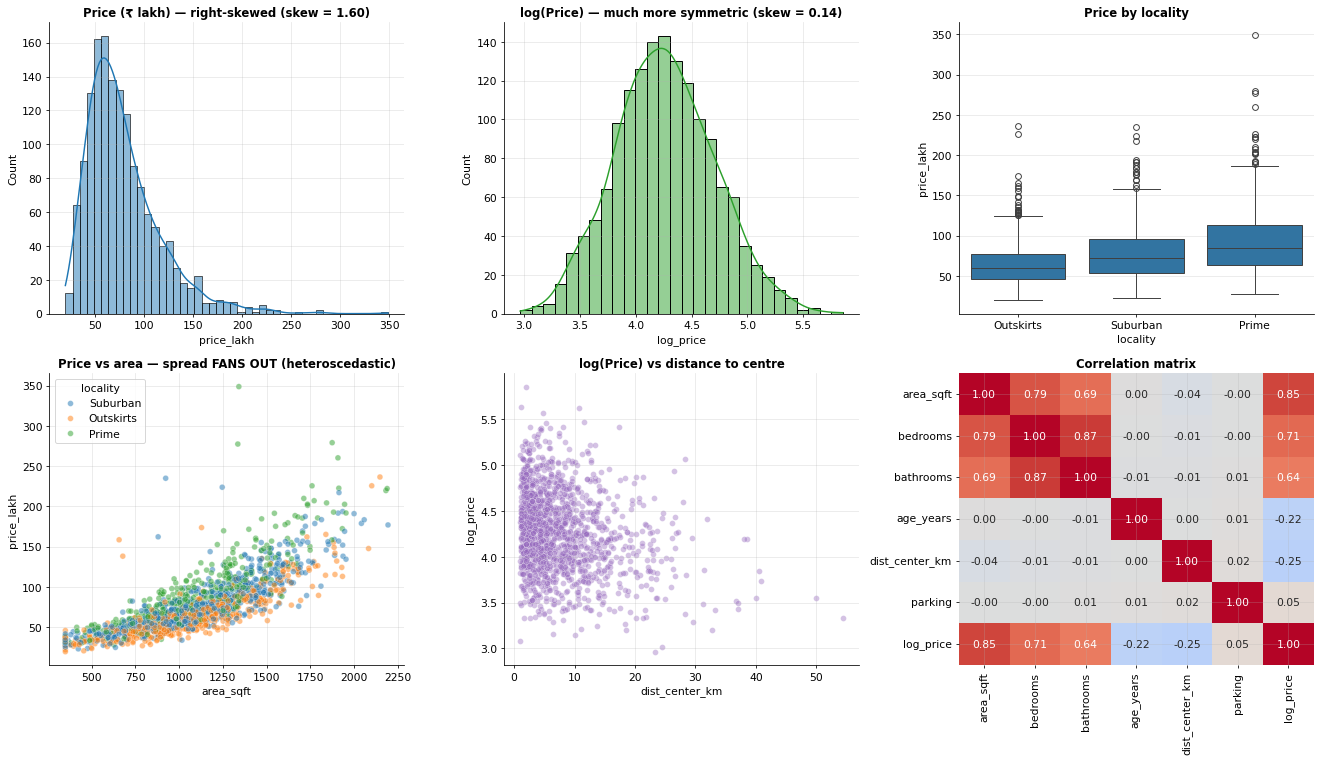

In [35]:
df["log_price"] = np.log(df["price_lakh"])
fig, ax = plt.subplots(2, 3, figsize=(19, 11))
sns.histplot(df["price_lakh"], kde=True, ax=ax[0, 0], color="tab:blue"); ax[0, 0].set_title(f"Price (₹ lakh) — right-skewed (skew = {df['price_lakh'].skew():.2f})")
sns.histplot(df["log_price"], kde=True, ax=ax[0, 1], color="tab:green"); ax[0, 1].set_title(f"log(Price) — much more symmetric (skew = {df['log_price'].skew():.2f})")
sns.boxplot(data=df, x="locality", y="price_lakh", order=["Outskirts", "Suburban", "Prime"], ax=ax[0, 2]); ax[0, 2].set_title("Price by locality")
sns.scatterplot(data=df, x="area_sqft", y="price_lakh", hue="locality", alpha=.5, ax=ax[1, 0]); ax[1, 0].set_title("Price vs area — spread FANS OUT (heteroscedastic)")
sns.scatterplot(data=df, x="dist_center_km", y="log_price", alpha=.4, ax=ax[1, 1], color="tab:purple"); ax[1, 1].set_title("log(Price) vs distance to centre")
corr = df[["area_sqft", "bedrooms", "bathrooms", "age_years", "dist_center_km", "parking", "log_price"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[1, 2], cbar=False); ax[1, 2].set_title("Correlation matrix")
plt.tight_layout(); plt.show()

**EDA findings → modelling decisions**

| Observation | Why it matters | Decision |
|---|---|---|
| Price is **right-skewed** and the scatter **fans out** with area | Violates constant-variance & normality; a *given* ₹ error matters less for expensive houses | Model **log(price)** — turns multiplicative effects into additive ones and stabilises variance |
| **Locality** clearly shifts price | Categorical predictor | **Dummy-encode** (baseline = *Outskirts*) |
| `area`, `bedrooms`, `bathrooms` are correlated | Possible multicollinearity → unstable coefficients | Check **VIF** |
| Some **missing** `age`, `dist` | Rows would be dropped otherwise | **Impute with training median** (learned on train only!) |
| A few **extreme prices** | Could distort OLS | Detect using model residuals |

### 11.6 Split first, then clean — *avoid data leakage*
Any statistic used to clean (medians, scalers) must come from the **training** data only; the test set plays the role of "future unseen listings".

In [36]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, random_state=42)
train, test = train.copy(), test.copy()

medians = train[["age_years", "dist_center_km"]].median()          # learned on TRAIN only
for d in (train, test):
    for c in medians.index:
        d[c] = d[c].fillna(medians[c])
print("Imputation medians (from train):", medians.round(2).to_dict())
print(f"train = {len(train)} rows, test = {len(test)} rows, missing left: {int(train.isna().sum().sum() + test.isna().sum().sum())}")

feature_cols = ["area_sqft", "bedrooms", "bathrooms", "age_years", "dist_center_km", "parking"]
def make_X(d):
    X = d[feature_cols].astype(float).copy()
    X["loc_Suburban"] = (d["locality"] == "Suburban").astype(float)     # baseline = Outskirts
    X["loc_Prime"]    = (d["locality"] == "Prime").astype(float)
    return X

X_train, X_test = make_X(train), make_X(test)
y_train, y_test = train["log_price"], test["log_price"]
display(X_train.head(3))

Imputation medians (from train): {'age_years': 14.7, 'dist_center_km': 5.4}
train = 1200 rows, test = 300 rows, missing left: 0


,area_sqft,bedrooms,bathrooms,age_years,dist_center_km,parking,loc_Suburban,loc_Prime
382,"1,434.0000",3.0000,2.0000,12.7000,9.4000,0.0000,0.0000,0.0000
538,"1,031.0000",2.0000,2.0000,13.7000,1.1000,1.0000,0.0000,1.0000
1493,"1,279.0000",3.0000,3.0000,23.5000,8.5000,1.0000,0.0000,0.0000


### 11.7 Multicollinearity check (VIF)
$\text{VIF}_j=1/(1-R_j^2)$ where $R_j^2$ comes from regressing feature $j$ on all the other features (Section 5.2).

,VIF
area_sqft,2.6789
bedrooms,5.9085
bathrooms,4.2657
age_years,1.0021
dist_center_km,1.0085
parking,1.0034
loc_Suburban,1.3365
loc_Prime,1.3425


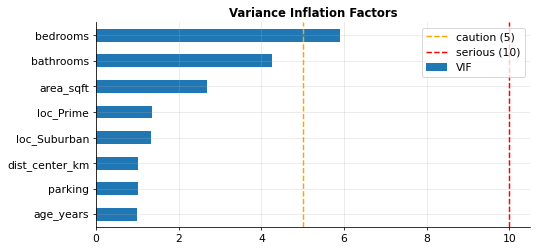

In [37]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn import metrics

def vif_table(X):
    out = {}
    for c in X.columns:
        others = X.drop(columns=c)
        r2 = LinearRegression().fit(others, X[c]).score(others, X[c])
        out[c] = 1 / (1 - r2)
    return pd.Series(out, name="VIF")

vif = vif_table(X_train)
display(vif.to_frame())
fig, ax = plt.subplots(figsize=(8, 3.8)); vif.sort_values().plot.barh(ax=ax, color="tab:blue")
ax.axvline(5, color="orange", ls="--", label="caution (5)"); ax.axvline(10, color="red", ls="--", label="serious (10)"); ax.set_title("Variance Inflation Factors"); ax.legend(); plt.show()

Most VIFs are close to 1. The exceptions are the three size-related features: `bedrooms` sits just above the "caution" line of 5 (≈6), `bathrooms` is a bit below it and `area_sqft` is low — but none is near the "serious" level of 10. Since we want to *interpret* these coefficients, we keep all three, but expect **wider confidence intervals for `bedrooms` and `bathrooms`** (Section 5.2: variance is inflated by the VIF). Had a VIF exceeded 10 we would drop or combine features (or use Ridge).

### 11.8 Baseline model & why we log-transform
Fit OLS to raw price and to log price; compare residual-vs-fitted plots.

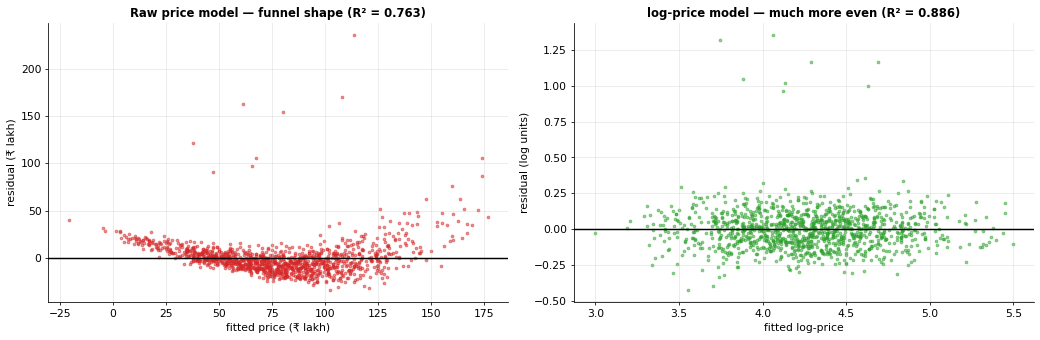

In [38]:
m_raw = LinearRegression().fit(X_train, train["price_lakh"])
m_log = LinearRegression().fit(X_train, y_train)
fit_raw, fit_log = m_raw.predict(X_train), m_log.predict(X_train)
res_raw, res_log = train["price_lakh"] - fit_raw, y_train - fit_log

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].scatter(fit_raw, res_raw, s=8, alpha=.5, color="tab:red"); ax[0].axhline(0, color="k")
ax[0].set(title=f"Raw price model — funnel shape (R² = {m_raw.score(X_train, train['price_lakh']):.3f})", xlabel="fitted price (₹ lakh)", ylabel="residual (₹ lakh)")
ax[1].scatter(fit_log, res_log, s=8, alpha=.5, color="tab:green"); ax[1].axhline(0, color="k")
ax[1].set(title=f"log-price model — much more even (R² = {m_log.score(X_train, y_train):.3f})", xlabel="fitted log-price", ylabel="residual (log units)")
plt.tight_layout(); plt.show()

The raw-price model shows a **funnel** (errors grow with price) and a few points far from the band; the log model is far better behaved. A handful of points in the log plot still sit far away — those are our suspected **data-entry errors**.

### 11.9 Detect suspicious records
Use a **robust z-score** of the residuals (median/MAD are not themselves distorted by the outliers): $z_i=e_i/\hat\sigma_{robust}$, with $\hat\sigma_{robust}=1.4826\cdot\text{median}(|e_i-\text{median}(e)|)$. Flag $|z|>4$.

Important real-world rule: **investigate before deleting** — a flagged record may be an error *or* a genuinely unusual property. Here we treat them as errors and apply the same rule (same model, same threshold) to the test set, since we can't fairly score predictions against wrongly-recorded labels.

robust σ = 0.121  (true noise sd = 0.12)
Flagged: 8 train rows, 0 test rows
Of all flagged rows, truly injected errors: 8 / 8 injected


,area_sqft,bedrooms,locality,price_lakh,expected_price,z
1040,923.0000,2,Suburban,234.9592,73.0000,9.7000
1371,"1,341.0000",3,Prime,348.8740,108.5000,9.6000
819,"1,246.0000",3,Suburban,223.8075,58.0000,11.2000
925,"1,335.0000",3,Prime,277.4848,102.3000,8.2000
884,678.0000,2,Outskirts,138.0945,48.4000,8.7000
1070,657.0000,1,Outskirts,158.4749,42.3000,10.9000
1411,880.0000,2,Suburban,162.1913,61.8000,8.0000
315,"1,128.0000",3,Outskirts,173.6430,62.5000,8.4000


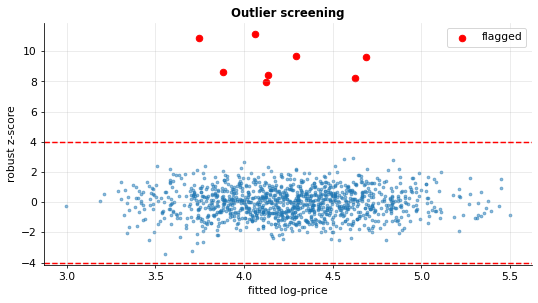


After cleaning → train 1192, test 300


In [39]:
mad = 1.4826 * np.median(np.abs(res_log - np.median(res_log)))
z_train = (res_log - np.median(res_log)) / mad
z_test  = ((y_test - m_log.predict(X_test)) - np.median(res_log)) / mad
flag_tr, flag_te = np.abs(z_train) > 4, np.abs(z_test) > 4
print(f"robust σ = {mad:.3f}  (true noise sd = 0.12)")
print(f"Flagged: {flag_tr.sum()} train rows, {flag_te.sum()} test rows")
print(f"Of all flagged rows, truly injected errors: {len((set(train.index[flag_tr]) | set(test.index[flag_te])) & set(bad_idx))} / {len(bad_idx)} injected")

display(train.loc[flag_tr, ["area_sqft", "bedrooms", "locality", "price_lakh"]].assign(expected_price=np.exp(fit_log[flag_tr.values]).round(1), z=z_train[flag_tr].round(1)).head(8))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(fit_log, z_train, s=8, alpha=.5); ax.scatter(fit_log[flag_tr.values], z_train[flag_tr], color="red", s=45, label="flagged")
ax.axhline(4, color="r", ls="--"); ax.axhline(-4, color="r", ls="--"); ax.set(xlabel="fitted log-price", ylabel="robust z-score", title="Outlier screening"); ax.legend(); plt.show()

train_c, test_c = train[~flag_tr.values], test[~flag_te.values]
X_train_c, X_test_c = X_train[~flag_tr.values], X_test[~flag_te.values]
y_train_c, y_test_c = y_train[~flag_tr.values], y_test[~flag_te.values]
print(f"\nAfter cleaning → train {len(train_c)}, test {len(test_c)}")

### 11.10 Final model with **statsmodels** — explain and defend the coefficients
The dependent variable is $\ln(\text{price})$, so the model is

$$
\ln(\text{price})=\beta_0+\beta_1\,\text{area}+\beta_2\,\text{bed}+\beta_3\,\text{bath}+\beta_4\,\text{age}+\beta_5\,\text{dist}+\beta_6\,\text{parking}+\beta_7\,\text{Suburban}+\beta_8\,\text{Prime}+\varepsilon
$$

**Interpreting coefficients in a log-linear model:** a one-unit increase in $x_j$ multiplies the price by $e^{\beta_j}$, i.e. changes it by $(e^{\beta_j}-1)\times100\%$ (≈ $100\beta_j\%$ when $\beta_j$ is small). A dummy's coefficient is the *percentage premium versus the baseline* (Outskirts).

In [ ]:
sm_final = sm.OLS(y_train_c, sm.add_constant(X_train_c)).fit()
print(sm_final.summary())

**What to check in this summary**
1. **F-test p ≈ 0** ⇒ the model is jointly significant. **R²** tells the share of *log-price* variance explained; the rest is mostly the noise we injected (σ = 0.12), so it can't be improved by this feature set.
2. **All coefficients' t-stats and CIs** — does each 95% CI exclude 0? Which are borderline?
3. **Cond. No.** is large simply because `area_sqft` is on a very different scale from the dummies (not necessarily a problem — VIFs are fine).
4. **Durbin–Watson** isn't meaningful here (rows are independent listings, not a time series).

Now translate coefficients into business language and compare with the *hidden truth* we used to generate the data:

In [40]:
lin_final = LinearRegression().fit(X_train_c, y_train_c)
coefs = pd.Series(lin_final.coef_, index=X_train_c.columns)
unit = {"area_sqft": 100}                                      # express area effect per +100 sq ft
effects = pd.DataFrame({
    "estimated coef": coefs,
    "true coef": pd.Series(TRUE),
    "per unit": [unit.get(c, 1) for c in coefs.index],
})
effects["% price change per unit (est.)"] = (np.exp(effects["estimated coef"] * effects["per unit"]) - 1) * 100
effects["% price change per unit (true)"] = (np.exp(effects["true coef"] * effects["per unit"]) - 1) * 100
display(effects)
print("Intercept:", round(lin_final.intercept_, 3), "(true 3.2)")

Intercept: 3.194 (true 3.2)


,estimated coef,true coef,per unit,% price change per unit (est.),% price change per unit (true)
area_sqft,0.0009,0.0009,100,9.5135,9.4174
bedrooms,0.0486,0.0400,1,4.9790,4.0811
bathrooms,0.0151,0.0300,1,1.5174,3.0455
age_years,-0.0119,-0.0120,1,-1.1833,-1.1928
dist_center_km,-0.0140,-0.0150,1,-1.3895,-1.4888
parking,0.0630,0.0600,1,6.4989,6.1837
loc_Suburban,0.1473,0.1500,1,15.8654,16.1834
loc_Prime,0.3318,0.3500,1,39.3505,41.9068


The regression recovers the mechanism closely for the big drivers (locality, area, age, distance, parking — usually within a fraction of a percentage point per unit). `bedrooms` and `bathrooms` are noticeably less precise (their estimates can be a percentage point or two off) because they overlap heavily with area, exactly as the multicollinearity discussion in Section 5.2 predicts. Compare the statsmodels confidence intervals with the true values: they should cover them in most rows.

### 11.11 Diagnostics on the final model

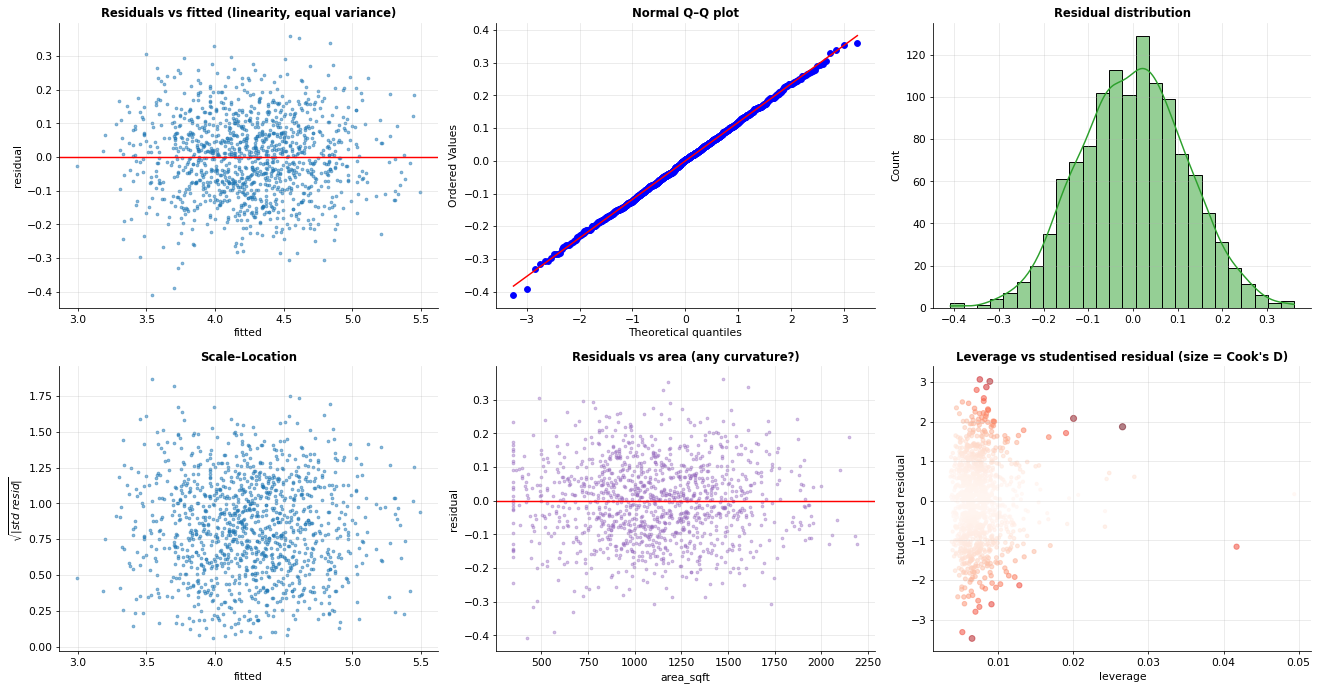

Breusch–Pagan p = 0.500   (H0: constant variance)
Shapiro–Wilk  p = 0.939   (H0: normal residuals)
Residual skew = -0.003, excess kurtosis = -0.102
Max Cook's D = 0.0106 (rule-of-thumb concern if > 1; 4/n = 0.0034)
Residual std (σ̂) = 0.118  (true 0.12)


In [41]:
fit_c = lin_final.predict(X_train_c); e = (y_train_c - fit_c).values
Xd = np.c_[np.ones(len(X_train_c)), X_train_c.values]; k_par = Xd.shape[1]; n_c = len(e)
s2_c = e @ e / (n_c - k_par)
h = np.einsum("ij,jk,ik->i", Xd, np.linalg.inv(Xd.T @ Xd), Xd)               # leverage
cook = e**2 / (k_par * s2_c) * h / (1 - h)**2

fig, ax = plt.subplots(2, 3, figsize=(19, 10))
ax[0, 0].scatter(fit_c, e, s=8, alpha=.5); ax[0, 0].axhline(0, color="r"); ax[0, 0].set(title="Residuals vs fitted (linearity, equal variance)", xlabel="fitted", ylabel="residual")
stats.probplot(e, dist="norm", plot=ax[0, 1]); ax[0, 1].set_title("Normal Q–Q plot")
sns.histplot(e, kde=True, ax=ax[0, 2], color="tab:green"); ax[0, 2].set_title("Residual distribution")
ax[1, 0].scatter(fit_c, np.sqrt(np.abs(e / e.std())), s=8, alpha=.5); ax[1, 0].set(title="Scale–Location", xlabel="fitted", ylabel=r"$\sqrt{|std\ resid|}$")
ax[1, 1].scatter(X_train_c["area_sqft"], e, s=8, alpha=.4, color="tab:purple"); ax[1, 1].axhline(0, color="r"); ax[1, 1].set(title="Residuals vs area (any curvature?)", xlabel="area_sqft", ylabel="residual")
ax[1, 2].scatter(h, e / np.sqrt(s2_c * (1 - h)), s=10 + 3000 * cook, alpha=.5, c=cook, cmap="Reds"); ax[1, 2].set(title="Leverage vs studentised residual (size = Cook's D)", xlabel="leverage", ylabel="studentised residual")
plt.tight_layout(); plt.show()

# formal tests
e2 = e**2; Xa = Xd; b_aux = np.linalg.lstsq(Xa, e2, rcond=None)[0]
r2_aux = 1 - ((e2 - Xa @ b_aux)**2).sum() / ((e2 - e2.mean())**2).sum()
bp_p = stats.chi2.sf(n_c * r2_aux, df=k_par - 1)
print(f"Breusch–Pagan p = {bp_p:.3f}   (H0: constant variance)")
print(f"Shapiro–Wilk  p = {stats.shapiro(e).pvalue:.3f}   (H0: normal residuals)")
print(f"Residual skew = {stats.skew(e):.3f}, excess kurtosis = {stats.kurtosis(e):.3f}")
print(f"Max Cook's D = {cook.max():.4f} (rule-of-thumb concern if > 1; 4/n = {4 / n_c:.4f})")
print(f"Residual std (σ̂) = {np.sqrt(s2_c):.3f}  (true 0.12)")

**Verdict:** residuals form a patternless band, follow the Normal line closely, no curvature vs area, no dangerous influential points. The **log transform fixed heteroscedasticity** and the classical assumptions are reasonably met, so the p-values/CIs from statsmodels can be trusted.

### 11.12 Predictive validation with **scikit-learn**
We now measure how well the model predicts **unseen** houses, in the units the business cares about (₹ lakh).

⚠️ **Back-transformation bias.** If $\ln y$ is predicted, $e^{\widehat{\ln y}}$ estimates the *median* of $y$, which is lower than the *mean* (Jensen's inequality). **Duan's smearing** corrects it: multiply by $\ \frac1n\sum e^{e_i}$ (mean of the exponentiated training residuals).

In [42]:
pipe_final = make_pipeline(StandardScaler(), LinearRegression())
kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_rmse = -cross_val_score(pipe_final, X_train_c, y_train_c, cv=kf, scoring="neg_root_mean_squared_error")
print(f"5-fold CV RMSE (log scale): {cv_rmse.round(4)}  → mean {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")

pipe_final.fit(X_train_c, y_train_c)
smear = np.mean(np.exp(y_train_c - pipe_final.predict(X_train_c)))
pred_log = pipe_final.predict(X_test_c)
y_true = test_c["price_lakh"].values

def report(y_t, y_p):
    return {"RMSE (₹ lakh)": np.sqrt(metrics.mean_squared_error(y_t, y_p)), "MAE (₹ lakh)": metrics.mean_absolute_error(y_t, y_p),
            "MAPE (%)": metrics.mean_absolute_percentage_error(y_t, y_p) * 100, "R²": metrics.r2_score(y_t, y_p)}

raw_model = LinearRegression().fit(X_train_c, train_c["price_lakh"])
results = pd.DataFrame({
    "1. Predict the average price":              report(y_true, np.full_like(y_true, train_c["price_lakh"].mean())),
    "2. Linear model on raw price":              report(y_true, raw_model.predict(X_test_c)),
    "3. Log-linear, naive back-transform":       report(y_true, np.exp(pred_log)),
    "4. Log-linear + Duan smearing (final)":     report(y_true, smear * np.exp(pred_log)),
}).T
print(f"\nSmearing factor = {smear:.4f}\n")
display(results)

5-fold CV RMSE (log scale): [0.1273 0.1112 0.1182 0.1232 0.1122]  → mean 0.1184 ± 0.0062

Smearing factor = 1.0069



,RMSE (₹ lakh),MAE (₹ lakh),MAPE (%),R²
1. Predict the average price,35.9680,27.8681,43.0994,-0.0000
2. Linear model on raw price,13.8397,10.6598,16.3023,0.8519
"3. Log-linear, naive back-transform",10.8001,8.2102,10.7102,0.9098
4. Log-linear + Duan smearing (final),10.7517,8.2197,10.7942,0.9106


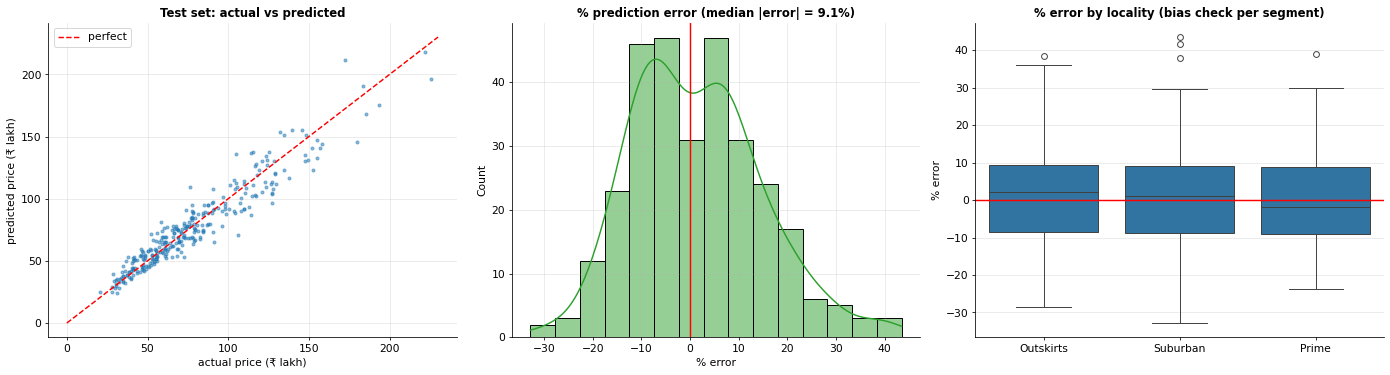

In [43]:
pred_price = smear * np.exp(pred_log)
pct_err = (pred_price - y_true) / y_true * 100

fig, ax = plt.subplots(1, 3, figsize=(20, 5.5))
lim = [0, max(y_true.max(), pred_price.max()) * 1.02]
ax[0].scatter(y_true, pred_price, s=10, alpha=.5); ax[0].plot(lim, lim, "r--", label="perfect"); ax[0].set(xlabel="actual price (₹ lakh)", ylabel="predicted price (₹ lakh)", title="Test set: actual vs predicted"); ax[0].legend()
sns.histplot(pct_err, kde=True, ax=ax[1], color="tab:green"); ax[1].axvline(0, color="r"); ax[1].set(title=f"% prediction error (median |error| = {np.median(np.abs(pct_err)):.1f}%)", xlabel="% error")
sns.boxplot(x=test_c["locality"].values, y=pct_err, order=["Outskirts", "Suburban", "Prime"], ax=ax[2]); ax[2].axhline(0, color="r"); ax[2].set(title="% error by locality (bias check per segment)", ylabel="% error")
plt.tight_layout(); plt.show()

### 11.13 Do we need regularisation?
With ~1,200 rows and 8 nearly-independent features, OLS has little variance to trade away. Let's verify rather than assume.

In [44]:
cands = {
    "OLS": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge (CV α)": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 40))),
    "Lasso (CV α)": make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=0)),
}
rows = []
for name, mdl in cands.items():
    cv_s = -cross_val_score(mdl, X_train_c, y_train_c, cv=kf, scoring="neg_root_mean_squared_error")
    mdl.fit(X_train_c, y_train_c)
    rows.append({"model": name, "CV RMSE (log)": cv_s.mean(), "test RMSE (log)": np.sqrt(metrics.mean_squared_error(y_test_c, mdl.predict(X_test_c))),
                 "non-zero coefs": int(np.sum(np.abs(mdl[-1].coef_) > 1e-8)), "α": getattr(mdl[-1], "alpha_", np.nan)})
display(pd.DataFrame(rows).set_index("model"))
print("→ Practically identical. Regularisation adds nothing here: keep the simple, fully interpretable OLS model. (Regularisation pays off with many/noisy/correlated features — Section 9.)")

→ Practically identical. Regularisation adds nothing here: keep the simple, fully interpretable OLS model. (Regularisation pays off with many/noisy/correlated features — Section 9.)


,CV RMSE (log),test RMSE (log),non-zero coefs,α
model,,,,
OLS,0.1184,0.1299,8,NaN
Ridge (CV α),0.1184,0.1299,8,0.8377
Lasso (CV α),0.1184,0.1300,8,0.0004


### 11.14 Which features matter most?
Two complementary views:
* **Standardised coefficients** (effect of a *1-standard-deviation* change) — allows fair comparison across features with different units.
* **Business what-ifs** — predicted price change if we alter one thing about a reference house.

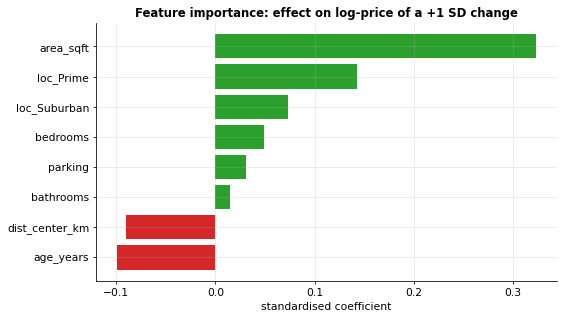

Reference house (1250 sq ft, 3BR/2BA, 8 yrs old, 6 km from centre, parking, Suburban):
   estimated price ≈ ₹94.0 lakh   (95% range: ₹74.7 – ₹118.0 lakh)

Share of test houses inside the 95% band: 93.0% (target ≈ 95%)


,new price (₹ lakh),change (₹ lakh),change (%)
scenario,,,
+1 bathroom,95.4556,1.4268,1.5174
+100 sq ft,102.9743,8.9455,9.5135
10 years older,83.4768,-10.5520,-11.2221
5 km farther from centre,87.6754,-6.3534,-6.7569
no parking,88.2909,-5.7379,-6.1023
in a Prime locality,113.0878,19.0590,20.2693
in the Outskirts,81.1535,-12.8753,-13.6929


In [45]:
std_coefs = pd.Series(pipe_final[-1].coef_, index=X_train_c.columns).sort_values()
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.barh(std_coefs.index, std_coefs.values, color=np.where(std_coefs.values > 0, "tab:green", "tab:red"))
ax.set(title="Feature importance: effect on log-price of a +1 SD change", xlabel="standardised coefficient"); plt.show()

# ---- Prediction for a specific listing + interval
res_tr = y_train_c - pipe_final.predict(X_train_c)
q_lo, q_hi = np.quantile(res_tr, [0.025, 0.975])                              # empirical 95% error band (log scale)
def predict_house(**kw):
    row = pd.DataFrame([{**dict(area_sqft=1250, bedrooms=3, bathrooms=2, age_years=8, dist_center_km=6, parking=1, loc_Suburban=1, loc_Prime=0), **kw}])[X_train_c.columns]
    pl = pipe_final.predict(row)[0]
    return smear * np.exp(pl), np.exp(pl + q_lo), np.exp(pl + q_hi)

base, lo, hi = predict_house()
print(f"Reference house (1250 sq ft, 3BR/2BA, 8 yrs old, 6 km from centre, parking, Suburban):")
print(f"   estimated price ≈ ₹{base:.1f} lakh   (95% range: ₹{lo:.1f} – ₹{hi:.1f} lakh)\n")

whatifs = {
    "+1 bathroom": dict(bathrooms=3), "+100 sq ft": dict(area_sqft=1350), "10 years older": dict(age_years=18),
    "5 km farther from centre": dict(dist_center_km=11), "no parking": dict(parking=0),
    "in a Prime locality": dict(loc_Suburban=0, loc_Prime=1), "in the Outskirts": dict(loc_Suburban=0, loc_Prime=0),
}
wf = pd.DataFrame([{"scenario": k, "new price (₹ lakh)": predict_house(**v)[0], "change (₹ lakh)": predict_house(**v)[0] - base, "change (%)": (predict_house(**v)[0] / base - 1) * 100} for k, v in whatifs.items()]).set_index("scenario")
display(wf)

# coverage of the empirical interval on the TEST set
res_te = y_test_c - pred_log
print(f"Share of test houses inside the 95% band: {np.mean((res_te >= q_lo) & (res_te <= q_hi)):.1%} (target ≈ 95%)")

### 11.15 Business conclusions & caveats

**What we learned (for the product team)**
1. **Location dominates**: a Prime address commands a large percentage premium over the Outskirts, and a Suburban one a smaller premium — nothing else in the model moves price as much per "step".
2. **Size matters steadily**: every +100 sq ft adds roughly 9–10% to the price *(multiplicative, so it is worth more ₹ on an expensive house)*.
3. **Age and distance are penalties**: about −1.2% per year of age and −1.5% per km from the centre.
4. **Bedrooms/bathrooms add little once area is known** — buyers pay for *space*, and extra rooms mostly re-partition the same space. (This is the "holding others constant" reading from Section 5.)
5. **The tool** can estimate a fair price with a typical error of roughly 10% and gives sellers an honest 95% range.

**Caveats — what a good analyst always states**
* **Association ≠ causation** — renovating won't necessarily raise price by the coefficient shown; unobserved factors (view, floor, amenities, builder reputation) are omitted and can bias effects.
* **Extrapolation** — the model is only reliable within the range of the training data (350–3000 sq ft etc.).
* **Data drift** — markets move; re-train regularly and monitor error by segment.
* **Data quality** — we removed records flagged as errors; in production, log them and send them for manual review rather than silently dropping.
* This dataset was **simulated**; on real data expect messier residuals, more omitted variables and a lower R².

**Next steps to improve:** add richer features (floor, amenities, micro-location, listing date), interactions (e.g. area × locality), non-linear terms (area²), robust standard errors, gradient-boosting as a benchmark, and geographic cross-validation.

---
## 12. Cheat-sheet, Pitfalls & Exercises

### 12.1 Formula sheet
| Concept | Formula |
|---|---|
| Model | $\mathbf y=\mathbf X\boldsymbol\beta+\boldsymbol\varepsilon$ |
| OLS estimator | $\hat{\boldsymbol\beta}=(\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top\mathbf y$ |
| Simple regression | $\hat\beta_1=S_{xy}/S_{xx}=r\,s_y/s_x,\ \ \hat\beta_0=\bar y-\hat\beta_1\bar x$ |
| Hat matrix | $\mathbf H=\mathbf X(\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top,\ \hat{\mathbf y}=\mathbf H\mathbf y$ |
| Error variance | $s^2=\text{SSE}/(n-p-1)$ |
| Covariance of $\hat\beta$ | $s^2(\mathbf X^\top\mathbf X)^{-1}$ |
| t-statistic / CI | $t=\hat\beta_j/\text{SE}_j;\ \ \hat\beta_j\pm t_{\alpha/2,n-p-1}\text{SE}_j$ |
| F-statistic | $\dfrac{\text{SSR}/p}{\text{SSE}/(n-p-1)}$ |
| $R^2$, adjusted $R^2$ | $1-\dfrac{\text{SSE}}{\text{SST}};\ \ 1-(1-R^2)\dfrac{n-1}{n-p-1}$ |
| MSE / RMSE / MAE | $\frac1n\sum e_i^2;\ \sqrt{\text{MSE}};\ \frac1n\sum\lvert e_i\rvert$ |
| Gradient descent | $\boldsymbol\theta\leftarrow\boldsymbol\theta-\frac\eta n\mathbf X^\top(\mathbf X\boldsymbol\theta-\mathbf y)$ |
| Ridge | $(\mathbf X^\top\mathbf X+\alpha\mathbf I)^{-1}\mathbf X^\top\mathbf y$ |
| Lasso objective | $\frac1{2n}\lVert\mathbf y-\mathbf X\boldsymbol\beta\rVert^2+\alpha\lVert\boldsymbol\beta\rVert_1$ |
| VIF | $1/(1-R_j^2)$ |
| Leverage / Cook's D | $h_{ii}=[\mathbf H]_{ii};\ \ D_i=\dfrac{e_i^2}{(p+1)s^2}\dfrac{h_{ii}}{(1-h_{ii})^2}$ |
| AIC / BIC | $2k-2\ell;\ \ k\ln n-2\ell$ |

### 12.2 Which loss / method when?
| Situation | Suggestion |
|---|---|
| Clean data, Gaussian-like errors | OLS (MSE) |
| Outliers / heavy tails | Huber, MAE (quantile) regression, robust SEs |
| Large errors much worse than small ones | MSE/RMSE |
| Errors are proportional to the level (money, counts) | model $\log y$, report MAPE or relative error |
| Many correlated features | Ridge / Elastic Net |
| Want feature selection | Lasso / Elastic Net |
| Huge data ($n$ or $p$ in millions) | SGD / mini-batch |
| Need p-values and CIs | statsmodels |
| Need a validated predictive pipeline | scikit-learn |

### 12.3 Common pitfalls
1. Judging a model on **training** $R^2$ only → use held-out data / CV.
2. **Leakage** — fitting scalers/imputers on all data before splitting.
3. Ignoring **residual plots** — a high $R^2$ can hide a curved relationship.
4. Reading coefficients causally, or comparing raw coefficients across different units.
5. **Extrapolating** beyond the range of the data.
6. The **dummy-variable trap** (all $k$ dummies + intercept).
7. Treating a non-significant coefficient as "no effect" (absence of evidence ≠ evidence of absence; look at the CI).
8. Forgetting `sm.add_constant` in statsmodels OLS.
9. Predicting on the log scale but reporting without back-transforming (and bias-correcting).
10. Blindly deleting outliers.

### 12.4 Exercises
1. Re-run Section 3.4 with `lr=0.5` on *unscaled* $x$. Why does it diverge? Compute $2/\lambda_{max}$ of $\mathbf X^\top\mathbf X/n$ to confirm.
2. In Section 2.8 add 10 outliers instead of 2 — which loss breaks first?
3. Prove that residuals sum to zero when the model includes an intercept (hint: first normal equation).
4. In the case study, add `area²` and an `area × Prime` interaction. Do AIC/BIC (statsmodels) improve? Does CV RMSE?
5. Replace the simulated data with the real *California Housing* dataset (`sklearn.datasets.fetch_california_housing`) and repeat the workflow. Which assumptions fail first?
6. Build 95% bootstrap confidence intervals for the coefficients (resample rows 1,000 times) and compare with statsmodels' analytic CIs.
7. Use `HuberRegressor` in the case study *instead of* removing flagged records. How do the coefficients and test errors compare?

### 12.5 Further reading
* *An Introduction to Statistical Learning* (James, Witten, Hastie, Tibshirani) — Ch. 3 & 6
* *The Elements of Statistical Learning* (Hastie, Tibshirani, Friedman) — Ch. 3
* *Applied Linear Regression Models* (Kutner et al.), *Regression Diagnostics* (Belsley et al.)
* statsmodels docs: https://www.statsmodels.org · scikit-learn user guide: https://scikit-learn.org/stable/modules/linear_model.html

**🎉 Congratulations — you've covered linear regression from first principles to production-style analysis.**